In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import pickle
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import train_test_split
from scipy.stats import mannwhitneyu
from scipy.spatial.distance import cdist
from sklearn.cluster import MiniBatchKMeans
import re
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

import sklearn, matplotlib, scipy
import tensorflow as tf
from tensorflow import keras

In [2]:
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

NumPy version: 1.24.4
Pandas version: 1.2.4
Scikit-learn version: 1.3.2
Matplotlib version: 3.4.1
Seaborn version: 0.11.1
SciPy version: 1.10.1
TensorFlow version: 2.7.0
Keras version: 2.7.0


In [12]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [15]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [3]:
## Definitions

## Defines

# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

def print_progress(iteration, total, prefix='', suffix='', decimals=1, length=50, fill='█', printEnd="\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end=printEnd)
    # Print New Line on Complete
    if iteration == total: 
        print()

In [4]:
## Configs
base = '/media/bami/JHA/24-07_nedis/KNN-ROP'
# out = f'{base}/Clustering/M01_Main'
# out = f'{base}/Clustering/M13/1_Whole'
out = f'{base}/Clustering/M03/PCA/GA25-27/PCA70/C5'
# out = f'{base}/Clustering/M01'
ipt = f'{base}/Dataset'
Z_dir = f'{base}/Clustering/M03/PCA/GA25-27/PCA70'
SEED = 64

In [14]:
# CLUSTERING :: DATA IMPORT

# Data import
# df = pd.read_csv(f"{ipt}/knn-ROP_prep_M04-alive.csv")
# df = pd.read_csv(f"{ipt}/knn-ROP_M04-alive_lmtGA30.csv")    # 1) GA < 30
df = pd.read_csv(f"{ipt}/knn-ROP_M04-alive_lmtGA28.csv")    # 2) GA < 28
# df = pd.read_csv(f"{ipt}/knn-ROP_M04-alive_lmtGA25.csv")    # 3-1) GA < 25
# df = pd.read_csv(f"{ipt}/knn-ROP_M04-alive_lmtGA25-27.csv")    #  3-2) GA 25 – 27.999

df.set_index('pid', inplace=True)
print(len(df.columns))
df

357


,sex_sys_val,birthdt,bir1,bir2,bir3,bir4,bird,admd,apgs1,apgs5,...,grwdd_m18-24,grwdd_m36,mendd,motdd,socdd,neudd,rop_severe,ventil_dur,oxyt28_Pos,oxyt36_Pos
pid,,,,,,,,,,,,,,,,,,,,,
1,1,2013-11-15,0.0,0.0,0.0,0.0,2013-11-15,2013-11-15,4.0,5.0,...,0,0,0,0,0,0,0,66,1,1
4,1,2013-11-11,0.0,0.0,0.0,0.0,2013-11-11,2013-11-11,4.0,5.0,...,0,0,0,0,0,0,0,29,0,0
15,1,2013-06-10,0.0,0.0,0.0,0.0,2013-06-10,2013-06-10,4.0,5.0,...,0,0,0,1,0,1,0,59,1,1
43,1,2013-07-05,0.0,0.0,0.0,0.0,2013-07-05,2013-07-05,4.0,8.0,...,0,0,0,0,0,0,1,91,1,1
44,1,2013-07-22,0.0,0.0,0.0,0.0,2013-07-22,2013-07-22,1.0,5.0,...,0,0,0,0,0,0,0,57,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16310,0,2020-06-24,0.0,0.0,0.0,0.0,2020-06-24,2020-06-24,2.0,5.0,...,0,0,0,0,0,0,0,63,1,1
16312,1,2020-06-23,0.0,0.0,0.0,0.0,2020-06-23,2020-06-23,1.0,6.0,...,0,0,0,0,0,0,1,84,1,0
16318,1,2020-11-01,0.0,0.0,0.0,0.0,2020-11-01,2020-11-01,2.0,4.0,...,0,0,0,0,0,0,0,61,1,0


In [15]:
for column in df.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df[column].dtype}")
    print(f"유니크한 값:")
    print(df[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: birthdt
데이터 타입: object
유니크한 값:
['2013-11-15' '2013-11-11' '2013-06-10' ... '2020-05-05' '2020-06-23'
 '2020-11-01']
----------------------------------------
칼럼 이름: bir1
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir2
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir3
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir4
데이터 타입: float64
유니크한 값:
[0.]
----------------------------------------
칼럼 이름: bird
데이터 타입: object
유니크한 값:
['2013-11-15' '2013-11-11' '2013-06-10' ... '2020-05-05' '2020-06-23'
 '2020-11-01']
----------------------------------------
칼럼 이름: admd
데이터 타입: object
유니크한 값:
['2013-11-15' '2013-11-11' '2013-06-10' ... '2020-05-05' '2020-06-23'
 '2020-11-01']
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 4.          1.          6.          7.          2.

[0 1]
----------------------------------------
칼럼 이름: eyedk21
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: eyedk22
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: eyedk23
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: eyed1
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: eyedk24
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: eyedk25
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: eyedk26
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: eyed2
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: hrd11
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: hrd12
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: hrd13
데이터 타입: int64
유니크한 값:
[0 1]
----------------------------------------
칼럼 이름: hrd14
데이터 타입: int64
유니크한

In [18]:
'''## 특정 칼럼의 값을 가진 인원만 사용

# col_name1 = 'iperr_2'
# col_name2 = 'ntet_1'
col_name = 'ntet_1'
value = 1

# df = df[(df[col_name1] == value) | (df[col_name2] == value)]    # 'OR' condition
df = df[df[col_name] == value]
num_rows = df.shape[0]
num_cols = df.shape[1]
summary_df = pd.DataFrame({
    'n_participants': [num_rows],
    'n_features': [num_cols]
})

file_name = col_name.split('_')[0] + '_Pos_DataSummary'
summary_df.to_csv(f"{out}/{file_name}.csv", index=False)
print(f"Data summary has been saved: {out}/{file_name}.csv")

df'''

Data summary has been saved: /media/bami/JHA/24-07_nedis/KNN-ROP/Clustering/M01/ntet_Pos_DataSummary.csv


,sex_sys_val,birthdt,bir1,bir2,bir3,bir4,bird,admd,apgs1,apgs5,...,wt2_z_who,ht2_z_who,hc2_z_who,grwdd_m18-24,grwdd_m36,mendd,motdd,socdd,neudd,rop_severe
pid,,,,,,,,,,,,,,,,,,,,,
4,1,2013-11-11,0.0,0.0,0.0,0.0,2013-11-11,2013-11-11,4.0,5.0,...,11.791700,22.227341,10.712332,0,0,0,0,0,0,0
44,1,2013-07-22,0.0,0.0,0.0,0.0,2013-07-22,2013-07-22,1.0,5.0,...,11.886335,21.268099,9.859863,0,0,0,0,0,0,0
109,0,2013-07-21,0.0,0.0,0.0,0.0,2013-07-21,2013-08-03,3.0,4.0,...,12.850472,23.015348,11.979996,0,0,0,0,0,0,0
134,0,2013-11-25,0.0,0.0,0.0,0.0,2013-11-25,2013-11-25,5.0,8.0,...,15.544633,24.079214,11.979996,0,0,0,0,0,0,1
135,0,2013-11-24,0.0,0.0,0.0,0.0,2013-11-24,2013-11-24,3.0,7.0,...,12.850472,23.015348,11.979996,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15993,0,2020-05-08,0.0,0.0,0.0,0.0,2020-05-08,2020-05-22,6.0,9.0,...,12.201211,20.858080,13.174144,0,0,0,0,0,0,1
16099,0,2020-01-30,0.0,1.0,0.0,0.0,2020-01-30,2020-01-30,4.0,6.0,...,12.008350,22.522333,11.065781,0,0,0,0,0,0,0
16110,0,2020-05-06,0.0,0.0,0.0,0.0,2020-05-06,2020-05-06,3.0,5.0,...,11.417540,21.824420,9.379092,0,0,0,1,0,1,0


In [ ]:
'''print(len(df.columns), '\n')

drop_cols = ['ga', 'sga', 'zonei']
print('len(drop_cols): ', len(drop_cols), '\n')


datetime_cols = ['ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt'
                 , 'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
                 , 'pmiodt', 'avegftrdt'
                ]
drop_cols += datetime_cols
print('len(drop_cols): ', len(drop_cols), '\n')


rsndth_cols = ['death_CR', 'death_NL', 'death_Inf', 'death_GI', 'death_CA', 'death_Otr']
drop_cols += rsndth_cols
print('len(drop_cols): ', len(drop_cols))
print("drop_cols:", drop_cols)
# df = df.drop(columns=list(drop_cols))

target_keys = ['ntet_', 'ntety_', 'ntetoy_'
               , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
               , 'NTET_day', 'PDA_7d_NTET'
               , 'invfpod'
               , 'iperr_', 'iperroy_'
               , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
               , 'IPERR_day', 'PDA_7d_IPERR', 'PDA_7d_IPERRorNTET'
               , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
               , 'sht', 'pmio_', 'avegftr', 'rop_severe'
               , '7d_PDA'
               , 'bdp', 'bdp_Moderate+', 'strdu_'
               , 'inhg_', 'pvl_', 'nese_'
               , 'seps_3'
               , 'pmirnsg_', 'pmirnsgnd'
               , 'stday'
               , 'oxyt36_', 'arre36_'
               , 'bwei', 'bhei', 'bhead'
               , 'dcdwt', 'dcdht', 'dcdcp'
              ]
tgt_cols = [col for col in df.columns
            if col in target_keys or any(col.startswith(prefix) for prefix in target_keys)
           ]
print('len(tgt_cols): ', len(tgt_cols))
print("tgt_cols:", tgt_cols)


data = df.drop(columns=['death_label'] + list(tgt_cols) + list(drop_cols)
#                + list(drop_cols)
#                + list(datetime_cols)
              )
print('len(data): ', len(data.columns), "--> drop(columns=['death_label'] + list(tgt_cols) + list(drop_cols)")
'''

In [39]:
'''# Column exclusion
KEEP_COLS = [
    "sex_sys_val","bir1","bir2","bir3","bir4","apgs1","apgs5","mage","gran","parn",
    "btem","btemuk","bbph","bbphuk","bbbe","bbbeuk","sftun","iarvppd","niarvrpd","aoxyuppd",
    "invfpod","sga","pda_non-treatment","pda_unknown","PDA_TRD","PPHN","ph_1","lbp_1","lbp_0",
    "chor_1","chor_0","chor_Unknown","ster_1","ster_0","ster_Unknown","atbyn_1","atbyn_0",
    "atbyn_Unknown","resu_1","resu_0","resu_Unknown","als_1","als_0","mph_1","mph_0","sft_1",
    "sft_0","strdu_1","strdu_0","nese_1","nese_0","meni_1","meni_0","prom_1","prom_0",
    "prom_Unknown","ntet_1","ntet_0","ntet_Unknown","eythtran_1","eythtran_0","inhg_0",
    "inhg_1+","inhg_3+","bdp","bdp_Moderate+","mulg_singleton","mulg_multiple","dm_0","dm_1",
    "delm_1","delm_2","htn_maternal","seps_eos","seps_los","prep_1","prep_2","htn_2","htn_1",
    "htn_3","amni_1","amni_2","amni_4","amni_3","bpia_1","bpia_2","bpia_3","oxyt28_1",
    "oxyt28_3","oxyt28_2","arre28_0","arre28_6","arre28_7","oxyt36_1","oxyt36_2","oxyt36_3",
    "arre36_0","arre36_6","arre36_7","pvl_1","pvl_2","seps_1","seps_2","seps_3","ntety_1",
    "ntety_2","iperr_1","iperr_2","sht_1","sht_3","sht_2"
]

def build_clustering_dataset_keep_only(df: pd.DataFrame, keep_cols=KEEP_COLS) -> pd.DataFrame:
    # 존재하는 칼럼만, 지정한 순서 그대로 추출
    present = [c for c in keep_cols if c in df.columns]
    missing = [c for c in keep_cols if c not in df.columns]
    out = df.loc[:, present].copy()
    print(f"[KeepOnly] requested={len(keep_cols)} | present={len(present)} | missing={len(missing)}")
    if missing:
        print("[Missing columns]", ", ".join(missing))
    return out

data = build_clustering_dataset_keep_only(df)'''

[KeepOnly] requested=111 | present=111 | missing=0


In [16]:
# Feature Exclusion :::: M01 11-12-2025

def build_clustering_dataset(df: pd.DataFrame) -> pd.DataFrame:
    # --- 보호 목록 ---
    keep_exact = {
        'pda_non-treatment','pda_unknown','PDA_TRD','PPHN','sftun',
        'iarvppd','niarvrpd','aoxyuppd',
        'ph_1','als_1','als_0','mph_1','mph_0','sft_1','sft_0',
        'bdp','bdp_Moderate+',
        'oxyt28_1','oxyt28_3','oxyt28_2','arre28_0','arre28_6','arre28_7',
        'oxyt36_1','oxyt36_2','oxyt36_3','arre36_0','arre36_6','arre36_7',
        'lbp_1','lbp_0','nese_1','nese_0','meni_1','meni_0',
        'inhg_0','inhg_1+','inhg_3+',
        'seps_eos','seps_los','pvl_1','pvl_2','seps_1','seps_2','seps_3',
        'invfpod','ntet_1','ntet_0','ntet_Unknown','eythtran_1','eythtran_0',
        'iperr_1','iperr_2',
        'ventil_dur', 'oxyt28_Pos', 'oxyt36_Pos'
        # ,'ntety_1','ntety_2','sht_1','sht_2','sht_3'    # Removed 11-19-2025
    }
    keep_prefixes = {'ntet_','iperr_','strdu_','inhg_','pvl_','nese_'
                     # ,'ntety_','sht_'    # Removed 11-19-2025
                     }

    def protected_cols(cols):
        out = set()
        for c in cols:
            if c in keep_exact:
                out.add(c); continue
            for p in keep_prefixes:
                if c.startswith(p):
                    out.add(c); break
        return out

    must_exclude = ['bbphuk', 'bbbeuk', 'pda_unknown', 'chor_Unknown', 'ster_Unknown'
                    , 'atbyn_Unknown', 'resu_Unknown', 'prom_Unknown', 'amni_4'
                   ]
    base_drop    = ['sga']           # 'ga'는 유지
    datetime_cols = [
        'ntetdt','ntetdty','date36','date362','menidt','pdaddth','pdaddt',
        'birthdt','admd','birtm','bird','efydt','death_dt','iperrdt',
        'bsfdt1','pmirnsgdt','pmiodt','avegftrdt'
    ]
    rsndth_cols = ['death_CR','death_NL','death_Inf','death_GI','death_CA','death_Otr']
    target_keys = [
        'ntet_','ntety_','ntetoy_','iperr_','iperroy_',
        'SEPS_bef_NTET','SEPS_aft_NTET','SEPS_bef_IPERR','SEPS_aft_IPERR',
        'SEPS_bef_IPERRorNTET','SEPS_aft_IPERRorNTET',
        'NTET_day','IPERR_day',
        'PDA_7d_NTET','PDA_7d_IPERR','PDA_7d_IPERRorNTET','7d_PDA',
        'invfpod','pmirnsg','pmirnsg_','pmirnsgnd',
        'sht','pmio_','avegftr','rop_severe',
        'bdp','bdp_Moderate+','strdu_','inhg_','pvl_','nese_','seps_3',
        'stday','bwei','bhei','bhead','dcdwt','dcdht','dcdcp'
    ]
    fu_prefixes = [
        'dthc1_','rhnyu1_','lgnyu1_','swnyu1_','hrd1_',
        'dthc2_','rhnyu2_','lgnyu2_','swnyu2_','hrd2_',
        'eyedk1','eyedk2','cp1_','cp2_',
        'leye1_','leye2_','glass1_','glass2_',
        'hrult1_','hrult2_','hrld1_','hrld2_','hrfc1_','hrfc2_',
        'rctr1_','rctr2_','lgtr1_','lgtr2_','shtr1_','shtr2_',
        'dgmtr1_','dgmtr2_','dfmtr1_','dfmtr2_','sctr1_','sctr2_',
        'eyed1','eyed2','hrd'
    ]
    fu_exact = [
        'vny1','vny2','wt1','wtuk1','wt2','wtuk2','ht1','htuk1','ht2','htuk2',
        'hc1','hcuk1','hc2','hcuk2','hr1','hr2','hr1_unknown','hr2_unknown',
        'gmfcs1','gmfcs2','mdi1','pdi1','cognit1','lang1','motor1',
        'mdi2','pdi2','cognit2','lang2','motor2',
        'ccpl1','gmpl1','fmpl1','pspl1','ispl1','ccpl2','gmpl2','fmpl2','pspl2','ispl2',
        'grwdd_m18-24','grwdd_m36','mendd','motdd','socdd','neudd',
        'wt1_z_who','ht1_z_who','hc1_z_who','wt2_z_who','ht2_z_who','hc2_z_who',
    ]
    disease_cols = [
        'eythtran_1','eythtran_0','lbp_1','lbp_0','meni_1','meni_0',
        'seps_eos','seps_los','seps_1','seps_2','sftun','iarvppd','niarvrpd','aoxyuppd',
        'ph_1','als_1','als_0','mph_1','mph_0','sft_1','sft_0',
        'oxyt28_1','oxyt28_3','oxyt28_2','arre28_0','arre28_6','arre28_7',
        'oxyt36_1','oxyt36_2','oxyt36_3','arre36_0','arre36_6','arre36_7',
        'pda_non-treatment','pda_unknown','PDA_TRD','PPHN','zonei','zonei_unknown'
    ]

    # --- Util ---
    def match_by_prefix(cols, prefixes):
        out = []
        for c in cols:
            for p in prefixes:
                if c.startswith(p):
                    out.append(c); break
        return sorted(set(out))

    def match_target_cols(cols, keys):
        out = []
        for c in cols:
            for k in keys:
                if c == k or c.startswith(k):
                    out.append(c); break
        return sorted(set(out))

    def n_groups(cols):
        heads = [x.split('_', 1)[0] for x in cols]
        return len(set(heads))

    # --- 후보 계산 ---
    present_must_excl = [c for c in must_exclude if c in df.columns]
    present_base_drop = [c for c in base_drop if c in df.columns]
    present_datetime  = [c for c in datetime_cols if c in df.columns]
    present_rsndth    = [c for c in rsndth_cols if c in df.columns]
    present_fu_exact  = [c for c in fu_exact if c in df.columns]
    present_fu_pref   = match_by_prefix(df.columns, fu_prefixes)
    present_fu        = sorted(set(present_fu_exact + present_fu_pref))
    present_tgt       = match_target_cols(df.columns, target_keys)
    present_disease   = [c for c in disease_cols if c in df.columns]

    candidates = sorted(set(
        present_must_excl + present_base_drop + present_datetime +
        present_rsndth + present_fu + present_tgt + present_disease
    ))

# 제외 예외 리스트 반영
    keep = protected_cols(df.columns)
    final_drops = [c for c in candidates if c not in keep]
    final_set   = set(final_drops)

# 실 제외 리스트
    ex_must   = [c for c in present_must_excl if c in final_set]
    ex_base   = [c for c in present_base_drop if c in final_set]
    ex_dt     = [c for c in present_datetime   if c in final_set]
    ex_rs     = [c for c in present_rsndth     if c in final_set]
    ex_tgt    = [c for c in present_tgt        if c in final_set]
    ex_fu_e   = [c for c in present_fu_exact   if c in final_set]
    ex_fu_p   = [c for c in present_fu_pref    if c in final_set]
    ex_fu     = sorted(set(ex_fu_e + ex_fu_p))
    ex_dis    = [c for c in present_disease    if c in final_set]

    print(f"[Counts] total_cols={df.shape[1]}")
    print(f" - must_exclude (Labels) : n={len(ex_must)} (groups={n_groups(ex_must)})")
    print(f" - base_drop    : n={len(ex_base)} (groups={n_groups(ex_base)})")
    print(f" - date-time     : n={len(ex_dt)} (groups={n_groups(ex_dt)})")
    print(f" - Reason-of-Death       : n={len(ex_rs)} (groups={n_groups(ex_rs)})")
    print(f" - target       : n={len(ex_tgt)} (groups={n_groups(ex_tgt)})")
    print(f" - FU(exact)    : n={len(ex_fu_e)} (groups={n_groups(ex_fu_e)})")
    print(f" - FU(prefix)   : n={len(ex_fu_p)} (groups={n_groups(ex_fu_p)})")
    print(f" - FU(total)    : n={len(ex_fu)} (groups={n_groups(ex_fu)})")
    print(f" - disease_cols : n={len(ex_dis)} (groups={n_groups(ex_dis)})")
    print(f"=> DROP all     : n={len(final_drops)} (groups={n_groups(final_drops)})")

    data = df.drop(columns=final_drops, errors='ignore').copy()
    kept_groups = n_groups(data.columns.tolist())
    print(f"[Result] kept_cols={data.shape[1]} (groups={kept_groups})")
    return data


data = build_clustering_dataset(df)
print("[Final] kept shape:", data.shape)
data

[Counts] total_cols=357
 - must_exclude (Labels) : n=8 (groups=8)
 - base_drop    : n=1 (groups=1)
 - date-time     : n=16 (groups=16)
 - Reason-of-Death       : n=6 (groups=1)
 - target       : n=35 (groups=21)
 - FU(exact)    : n=52 (groups=43)
 - FU(prefix)   : n=146 (groups=54)
 - FU(total)    : n=198 (groups=97)
 - disease_cols : n=2 (groups=1)
=> DROP all     : n=256 (groups=140)
[Result] kept_cols=101 (groups=55)
[Final] kept shape: (2551, 101)


,sex_sys_val,bir1,bir2,bir3,bir4,apgs1,apgs5,mage,gran,parn,...,pvl_1,pvl_2,seps_1,seps_2,seps_3,iperr_1,iperr_2,ventil_dur,oxyt28_Pos,oxyt36_Pos
pid,,,,,,,,,,,,,,,,,,,,,
1,1,0.0,0.0,0.0,0.0,4.0,5.0,35,1,0,...,1,0,0,1,0,1,0,66,1,1
4,1,0.0,0.0,0.0,0.0,4.0,5.0,36,4,1,...,1,0,1,0,0,1,0,29,0,0
15,1,0.0,0.0,0.0,0.0,4.0,5.0,34,1,0,...,1,0,1,0,0,1,0,59,1,1
43,1,0.0,0.0,0.0,0.0,4.0,8.0,35,4,2,...,1,0,1,0,0,1,0,91,1,1
44,1,0.0,0.0,0.0,0.0,1.0,5.0,32,1,0,...,1,0,1,0,0,1,0,57,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16310,0,0.0,0.0,0.0,0.0,2.0,5.0,40,2,0,...,0,1,1,0,0,1,0,63,1,1
16312,1,0.0,0.0,0.0,0.0,1.0,6.0,39,9,6,...,0,1,0,1,0,1,0,84,1,0
16318,1,0.0,0.0,0.0,0.0,2.0,4.0,37,2,1,...,0,1,0,1,0,1,0,61,1,0


In [48]:
'''
# 기존 세팅
def build_clustering_dataset(df: pd.DataFrame) -> pd.DataFrame:
    # 0) 항상 제외(라벨)
    must_exclude = ['']    # death_label

    # 1) 단일 드랍
    base_drop = ['sga']    # 'ga'

    # 2) 날짜
    datetime_cols = [
        'ntetdt','ntetdty','date36','date362','menidt','pdaddth','pdaddt',
        'birthdt','admd','birtm','bird','efydt','death_dt','iperrdt',
        'bsfdt1','pmirnsgdt','pmiodt','avegftrdt'
    ]

    # 3) 사망원인
    rsndth_cols = ['death_CR','death_NL','death_Inf','death_GI','death_CA','death_Otr']

    # 4) 타깃/사건 관련 (프리픽스 매칭)
    target_keys = [
        'ntet_', 'ntety_', 'ntetoy_', 'iperr_', 'iperroy_',
        'SEPS_bef_NTET','SEPS_aft_NTET','SEPS_bef_IPERR','SEPS_aft_IPERR',
        'SEPS_bef_IPERRorNTET','SEPS_aft_IPERRorNTET',
        'NTET_day','IPERR_day',
        'PDA_7d_NTET','PDA_7d_IPERR','PDA_7d_IPERRorNTET','7d_PDA',
        'invfpod','pmirnsg','pmirnsg_','pmirnsgnd',
        'sht','pmio_','avegftr','rop_severe',
        'bdp','bdp_Moderate+','strdu_','inhg_','pvl_','nese_','seps_3',
        'stday','bwei','bhei','bhead','dcdwt','dcdht','dcdcp'
    ]

    # 5) FU 계열
    fu_prefixes = [
        # 요청에서 명시한 것들
        'dthc1_','rhnyu1_','lgnyu1_','swnyu1_','hrd1_',
        'dthc2_','rhnyu2_','lgnyu2_','swnyu2_','hrd2_',
        'eyedk1','eyedk2','cp1_','cp2_',
        'leye1_','leye2_','glass1_','glass2_',
        'hrult1_','hrult2_','hrld1_','hrld2_','hrfc1_','hrfc2_',
        'rctr1_','rctr2_','lgtr1_','lgtr2_','shtr1_','shtr2_',
        'dgmtr1_','dgmtr2_','dfmtr1_','dfmtr2_','sctr1_','sctr2_',
        'eyed1', 'eyed2', 'hrd'
    ]
    fu_exact = [
        'vny1','vny2',
        'wt1','wtuk1','wt2','wtuk2',
        'ht1','htuk1','ht2','htuk2',
        'hc1','hcuk1','hc2','hcuk2',
        'hr1','hr2',
        'hr1_unknown','hr2_unknown',
        'gmfcs1','gmfcs2',
        'mdi1','pdi1','cognit1','lang1','motor1',
        'mdi2','pdi2','cognit2','lang2','motor2',
        'ccpl1','gmpl1','fmpl1','pspl1','ispl1',
        'ccpl2','gmpl2','fmpl2','pspl2','ispl2',
        'grwdd_m18-24','grwdd_m36','mendd','motdd','socdd','neudd',
        'wt1_z_who','ht1_z_who','hc1_z_who',
        'wt2_z_who','ht2_z_who','hc2_z_who',
    ]
    
    # 질환/사건 개별 컬럼 (규칙에 안 걸리는 것들)
    disease_cols = [
        'eythtran_1','eythtran_0','lbp_1','lbp_0','meni_1','meni_0',
        'seps_eos','seps_los','seps_1','seps_2','sftun','iarvppd','niarvrpd','aoxyuppd',
        'ph_1','als_1','als_0','mph_1','mph_0','sft_1','sft_0',
        'oxyt28_1','oxyt28_3','oxyt28_2','arre28_0','arre28_6','arre28_7',
        'oxyt36_1','oxyt36_2','oxyt36_3','arre36_0','arre36_6','arre36_7',
        'pda_non-treatment','pda_unknown','PDA_TRD','PPHN', 'zonei', 'zonei_unknown'
    ]

    # Util
    def match_by_prefix(cols, prefixes):
        out = []
        for c in cols:
            for p in prefixes:
                if c.startswith(p):
                    out.append(c); break
        return sorted(set(out))

    def match_target_cols(cols, keys):
        out = []
        for c in cols:
            for k in keys:
                if c == k or c.startswith(k):
                    out.append(c); break
        return sorted(set(out))

    def n_groups(cols):
        heads = [x.split('_', 1)[0] for x in cols]
        return len(set(heads))

    # matchings
    present_must_excl = [c for c in must_exclude if c in df.columns]
    present_base_drop = [c for c in base_drop if c in df.columns]
    present_datetime  = [c for c in datetime_cols if c in df.columns]
    present_rsndth    = [c for c in rsndth_cols if c in df.columns]
    present_fu_exact  = [c for c in fu_exact if c in df.columns]
    present_fu_pref   = match_by_prefix(df.columns, fu_prefixes)
    present_fu        = sorted(set(present_fu_exact + present_fu_pref))
    present_tgt       = match_target_cols(df.columns, target_keys)
    present_disease = [c for c in disease_cols if c in df.columns]

    cols_to_drop = sorted(set(
        present_must_excl + present_base_drop + present_datetime +
        present_rsndth + present_fu + present_tgt + present_disease
    ))

    # ---------- 리포트 ----------
    print(f"[Counts] total_cols={df.shape[1]}")
    print(f" - must_exclude (Labels) : n={len(present_must_excl)} (groups={n_groups(present_must_excl)})")
    print(f" - base_drop    : n={len(present_base_drop)} (groups={n_groups(present_base_drop)})")
    print(f" - datetime     : n={len(present_datetime)} (groups={n_groups(present_datetime)})")
    print(f" - rsndth       : n={len(present_rsndth)} (groups={n_groups(present_rsndth)})")
    print(f" - target       : n={len(present_tgt)} (groups={n_groups(present_tgt)})")
    print(f" - FU(exact)    : n={len(present_fu_exact)} (groups={n_groups(present_fu_exact)})")
    print(f" - FU(prefix)   : n={len(present_fu_pref)} (groups={n_groups(present_fu_pref)})")
    print(f" - FU(total)    : n={len(present_fu)} (groups={n_groups(present_fu)})")
    print(f" - disease_cols : n={len(present_disease)} (groups={n_groups(present_disease)})")
    print(f"=> DROP all     : n={len(cols_to_drop)} (groups={n_groups(cols_to_drop)})")

    # ---------- 최종 DF ----------
    data = df.drop(columns=cols_to_drop, errors='ignore').copy()
    kept_groups = n_groups(data.columns.tolist())
    print(f"[Result] kept_cols={data.shape[1]} (groups={kept_groups})")
    return data


data = build_clustering_dataset(df)
print("[Final] kept shape:", data.shape)
data
'''

[Counts] total_cols=354
 - must_exclude (Labels) : n=0 (groups=0)
 - base_drop    : n=1 (groups=1)
 - datetime     : n=16 (groups=16)
 - rsndth       : n=6 (groups=1)
 - target       : n=53 (groups=30)
 - FU(exact)    : n=52 (groups=43)
 - FU(prefix)   : n=146 (groups=54)
 - FU(total)    : n=198 (groups=97)
 - disease_cols : n=39 (groups=20)
=> DROP all     : n=303 (groups=159)
[Result] kept_cols=51 (groups=29)
[Final] kept shape: (3904, 51)


,sex_sys_val,bir1,bir2,bir3,bir4,apgs1,apgs5,mage,gran,parn,...,htn_2,htn_1,htn_3,amni_1,amni_2,amni_4,amni_3,bpia_1,bpia_2,bpia_3
pid,,,,,,,,,,,,,,,,,,,,,
1,1,0.0,0.0,0.0,0.0,4.0,5.0,35,1,0,...,0,1,0,1,0,0,0,1,0,0
4,1,0.0,0.0,0.0,0.0,4.0,5.0,36,4,1,...,0,1,0,1,0,0,0,1,0,0
15,1,0.0,0.0,0.0,0.0,4.0,5.0,34,1,0,...,0,1,0,1,0,0,0,1,0,0
43,1,0.0,0.0,0.0,0.0,4.0,8.0,35,4,2,...,0,1,0,1,0,0,0,1,0,0
44,1,0.0,0.0,0.0,0.0,1.0,5.0,32,1,0,...,0,1,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16318,1,0.0,0.0,0.0,0.0,2.0,4.0,37,2,1,...,0,1,0,1,0,0,0,1,0,0
16320,0,0.0,0.0,0.0,0.0,1.0,3.0,33,2,0,...,0,1,0,0,1,0,0,1,0,0
16322,1,1.0,0.0,0.0,0.0,3.0,5.0,36,3,1,...,0,1,0,1,0,0,0,1,0,0


In [49]:
'''
## Residualise


def residualise_with_ga_sex(data: pd.DataFrame, df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    data   : (질환/사건 제거 후) 클러스터링 후보 칼럼만 남긴 DF
    df_raw : 원본 DF (ga, sex_sys_val 포함) — 같은 인덱스 정렬 가정
    반환   : 연속형만 잔차화된 DF (이진 {0,1} 칼럼은 원값 유지), 열/순서 동일
    * NaN/결측/임퓨테이션은 이미 완료되었다고 가정
    """
    # 공변량 행렬
    C = df_raw.loc[data.index, ["ga", "sex_sys_val"]]

    # 이진/연속 구분
    binary_cols = [c for c in data.columns if set(data[c].unique()) <= {0, 1}]
    cont_cols   = [c for c in data.columns if c not in binary_cols]

    # 결과 DF 골격
    resid = pd.DataFrame(index=data.index, columns=data.columns, dtype=float)

    # 이진은 원값 유지
    if binary_cols:
        resid[binary_cols] = data[binary_cols].astype(float)

    # 연속형은 OLS 잔차 r = y - Xβ
    for c in cont_cols:
        y = data[c].values
        m = LinearRegression().fit(C, y)
        resid[c] = y - m.predict(C)

    print(f"[Residualise] covariates used=['ga','sex_sys_val'] | "
          f"residualised(continuous)={len(cont_cols)} | passthrough(binary)={len(binary_cols)}")
    return resid


resid = residualise_with_ga_sex(data, df)
# resid = resid.drop(columns=['ga'], errors='ignore')

data = resid.drop(columns=['ga'], errors='ignore')
data
'''

[Residualise] covariates used=['ga','sex_sys_val'] | residualised(continuous)=9 | passthrough(binary)=42


,sex_sys_val,bir1,bir2,bir3,bir4,apgs1,apgs5,mage,gran,parn,...,htn_2,htn_1,htn_3,amni_1,amni_2,amni_4,amni_3,bpia_1,bpia_2,bpia_3
pid,,,,,,,,,,,,,,,,,,,,,
1,1.0,0.0,0.0,0.0,0.0,0.206846,-1.229208,1.682890,-0.999795,-0.498257,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,-0.163246,-1.553063,2.662878,2.036055,0.520170,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
15,1.0,0.0,0.0,0.0,0.0,0.124606,-1.301173,0.678443,-0.991829,-0.494162,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
43,1.0,0.0,0.0,0.0,0.0,0.988164,2.454496,1.725138,1.924520,1.462842,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
44,1.0,0.0,0.0,0.0,0.0,-3.245486,-1.625028,-1.341569,-0.955979,-0.475736,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16318,1.0,0.0,0.0,0.0,0.0,-1.217449,-1.725429,3.714020,-0.055562,0.473079,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
16320,0.0,0.0,0.0,0.0,0.0,-3.470773,-3.750962,-0.489036,-0.006694,-0.489380,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
16322,1.0,1.0,0.0,0.0,0.0,-0.464168,-0.941324,2.700679,0.968337,0.485363,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [51]:
'''
## Verify Residualisation

# ===== 0) 연속/이진 분리 =====
binary_cols = [c for c in data.columns if set(data[c].dropna().unique()) <= {0, 1}]
cont_cols   = [c for c in data.columns if c not in binary_cols]

print(f"[INFO] binary={len(binary_cols)} | continuous={len(cont_cols)}")

# ===== 1) 공변량 행렬(ga, sex_sys_val) =====
ga  = df.loc[data.index, "ga"].astype(float).values.reshape(-1, 1)
sex = df.loc[data.index, "sex_sys_val"].astype(float).values.reshape(-1, 1)
C   = np.hstack([ga, sex])

# ===== 2) 각 연속형 컬럼에 대해 corr/R² 계산 =====
corr_ga, corr_sex, r2s = [], [], []
for c in cont_cols:
    y = data[c].astype(float).values
    corr_ga.append(np.corrcoef(y, ga.ravel())[0, 1])
    corr_sex.append(np.corrcoef(y, sex.ravel())[0, 1])
    m = LinearRegression().fit(C, y)
    r2s.append(m.score(C, y))

summary = pd.DataFrame({
    "feature": cont_cols,
    "corr_with_ga": corr_ga,
    "corr_with_sex": corr_sex,
    "abs_corr_ga": np.abs(corr_ga),
    "abs_corr_sex": np.abs(corr_sex),
    "R2_on_[ga,sex]": r2s
}).sort_values("R2_on_[ga,sex]", ascending=False).reset_index(drop=True)

# ===== 3) 출력 포맷(공학표기 금지, .5f, 아주 작은 값은 '< 0.00001') =====
THRESH_PRINT = 1e-5
def fmt5(x: float) -> str:
    try:
        x = float(x)
    except Exception:
        return str(x)
    return "< 0.00001" if abs(x) < THRESH_PRINT else f"{x:.5f}"

def format_summary_df(df_in: pd.DataFrame, numeric_cols=None) -> pd.DataFrame:
    if numeric_cols is None:
        numeric_cols = df_in.select_dtypes(include=["number"]).columns.tolist()
    df_out = df_in.copy()
    for c in numeric_cols:
        df_out[c] = df_out[c].map(fmt5)
    return df_out

# 요약 지표(임계치는 참고용)
THRESH_ABS_CORR = 0.05
THRESH_R2 = 0.01

mean_abs_corr_ga  = np.mean(np.abs(summary["corr_with_ga"]))
mean_abs_corr_sex = np.mean(np.abs(summary["corr_with_sex"]))
median_r2         = np.median(summary["R2_on_[ga,sex]"])
n_fail = ((np.abs(summary["corr_with_ga"])  > THRESH_ABS_CORR) |
          (np.abs(summary["corr_with_sex"]) > THRESH_ABS_CORR) |
          (summary["R2_on_[ga,sex]"]        > THRESH_R2)).sum()

print("[CHECK - continuous only]")
print(" mean |corr(r,ga)|   :", fmt5(mean_abs_corr_ga))
print(" mean |corr(r,sex)|  :", fmt5(mean_abs_corr_sex))
print(" median R2           :", fmt5(median_r2))
print(f" features exceeding thresholds: {int(n_fail)} / {len(cont_cols)} "
      f"(abs_corr>{THRESH_ABS_CORR:.2f} or R2>{THRESH_R2:.2f})")

# 전체 연속형 피처 결과를 지정 포맷으로 출력
cols_to_show = ["feature","corr_with_ga","corr_with_sex","R2_on_[ga,sex]"]
summary_fmt = format_summary_df(summary[cols_to_show], numeric_cols=[c for c in cols_to_show if c != "feature"])
print("\n[Per-feature metrics for ALL continuous columns]")
print(summary_fmt.to_string(index=False))
'''

[INFO] binary=42 | continuous=8
[CHECK - continuous only]
 mean |corr(r,ga)|   : < 0.00001
 mean |corr(r,sex)|  : < 0.00001
 median R2           : < 0.00001
 features exceeding thresholds: 0 / 8 (abs_corr>0.05 or R2>0.01)

[Per-feature metrics for ALL continuous columns]
feature corr_with_ga corr_with_sex R2_on_[ga,sex]
   gran    < 0.00001     < 0.00001      < 0.00001
  apgs1    < 0.00001     < 0.00001      < 0.00001
  apgs5    < 0.00001     < 0.00001      < 0.00001
   mage    < 0.00001     < 0.00001      < 0.00001
   parn    < 0.00001     < 0.00001      < 0.00001
   btem    < 0.00001     < 0.00001      < 0.00001
   bbph    < 0.00001     < 0.00001      < 0.00001
   bbbe    < 0.00001     < 0.00001      < 0.00001


In [17]:
# Feature confirmmation
vz = data.var(numeric_only=True).eq(0)
zero_vars = vz[vz].index.tolist()

print("zero-variance columns (count):", len(zero_vars))
print("names:", zero_vars)

zero-variance columns (count): 5
names: ['bir4', 'ntet_Unknown', 'seps_eos', 'seps_los', 'seps_3']


In [18]:
# Non-Residualisation
data = data.drop(columns=['ga'
                          , 'bir4'    # Added : 11-12-2025, 다태아 중 출생 순서 4th 이상
                          , 'ntet_Unknown'    # Added : 11-12-2025
                          , 'seps_eos', 'seps_los'    # Added : 11-12-2025, Early/Late onset SEPS
                          , 'seps_3'    # Added : 11-12-2025, SEPS_혈액배양 미시행
                         ], errors='ignore')

data

,sex_sys_val,bir1,bir2,bir3,apgs1,apgs5,mage,gran,parn,btem,...,arre36_7,pvl_1,pvl_2,seps_1,seps_2,iperr_1,iperr_2,ventil_dur,oxyt28_Pos,oxyt36_Pos
pid,,,,,,,,,,,,,,,,,,,,,
1,1,0.0,0.0,0.0,4.0,5.0,35,1,0,36.5,...,0,1,0,0,1,1,0,66,1,1
4,1,0.0,0.0,0.0,4.0,5.0,36,4,1,37.0,...,0,1,0,1,0,1,0,29,0,0
15,1,0.0,0.0,0.0,4.0,5.0,34,1,0,37.0,...,0,1,0,1,0,1,0,59,1,1
43,1,0.0,0.0,0.0,4.0,8.0,35,4,2,34.7,...,1,1,0,1,0,1,0,91,1,1
44,1,0.0,0.0,0.0,1.0,5.0,32,1,0,35.3,...,0,1,0,1,0,1,0,57,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16310,0,0.0,0.0,0.0,2.0,5.0,40,2,0,36.4,...,1,0,1,1,0,1,0,63,1,1
16312,1,0.0,0.0,0.0,1.0,6.0,39,9,6,36.4,...,0,0,1,0,1,1,0,84,1,0
16318,1,0.0,0.0,0.0,2.0,4.0,37,2,1,35.9,...,0,0,1,0,1,1,0,61,1,0


In [19]:
for column in data.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {data[column].dtype}")
    print(f"유니크한 값:")
    print(data[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: bir1
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir2
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir3
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 4.          1.          6.          7.          2.          5.
  3.          0.          4.02442183  8.         10.          9.        ]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[ 5.          8.         10.          6.          7.          4.
  3.          1.          2.          6.21611954  9.          0.        ]
----------------------------------------
칼럼 이름: mage
데이터 타입: int64
유니크한 값:
[35 36 34 32 37 33 31 29 28 39 38 30 43 24 23 27 41 25 26 40 18 22 21 44
 19 20 47 45 42 46 49 17]
----------------------------------------
칼럼 이름: gran
데이터 타입: int64
유니크한 값:
[ 1  4  3  2  5

In [20]:
## Scaling

binary_cols = []
for col in data.columns:
    unique_vals = set(data[col].dropna().unique())
    if unique_vals.issubset({0, 1}):
        binary_cols.append(col)
continuous_cols = [col for col in data.columns if col not in binary_cols]

print("Binary cols:", len(binary_cols))
for col in binary_cols:
    print(f"- {col}")
print("\nContinuous cols:", len(continuous_cols))
for col in continuous_cols:
    print(f"- {col}")
print('len(data): ', len(data.columns))


scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[continuous_cols])
df_scd = pd.concat([
    pd.DataFrame(scaled_data, index=data.index, columns=continuous_cols),
    data[binary_cols]
], axis=1)
df_scd = df_scd[data.columns]

# df_scd['death_label'] = df['death_label']
df_scd

Binary cols: 81
- sex_sys_val
- bir1
- bir2
- bir3
- btemuk
- pda_non-treatment
- pda_unknown
- PDA_TRD
- PPHN
- ph_1
- lbp_1
- lbp_0
- chor_1
- chor_0
- ster_1
- ster_0
- atbyn_1
- atbyn_0
- resu_1
- resu_0
- als_1
- als_0
- mph_1
- mph_0
- sft_1
- sft_0
- strdu_1
- strdu_0
- nese_1
- nese_0
- meni_1
- meni_0
- prom_1
- prom_0
- ntet_1
- ntet_0
- eythtran_1
- eythtran_0
- inhg_0
- inhg_1+
- inhg_3+
- bdp
- bdp_Moderate+
- mulg_singleton
- mulg_multiple
- dm_0
- dm_1
- delm_1
- delm_2
- htn_maternal
- prep_1
- prep_2
- htn_2
- htn_1
- htn_3
- amni_1
- amni_2
- amni_3
- bpia_1
- bpia_2
- bpia_3
- oxyt28_1
- oxyt28_3
- oxyt28_2
- arre28_0
- arre28_6
- arre28_7
- oxyt36_1
- oxyt36_2
- oxyt36_3
- arre36_0
- arre36_6
- arre36_7
- pvl_1
- pvl_2
- seps_1
- seps_2
- iperr_1
- iperr_2
- oxyt28_Pos
- oxyt36_Pos

Continuous cols: 14
- apgs1
- apgs5
- mage
- gran
- parn
- btem
- bbph
- bbbe
- sftun
- iarvppd
- niarvrpd
- aoxyuppd
- invfpod
- ventil_dur
len(data):  95


,sex_sys_val,bir1,bir2,bir3,apgs1,apgs5,mage,gran,parn,btem,...,arre36_7,pvl_1,pvl_2,seps_1,seps_2,iperr_1,iperr_2,ventil_dur,oxyt28_Pos,oxyt36_Pos
pid,,,,,,,,,,,,,,,,,,,,,
1,1,0.0,0.0,0.0,0.112074,-0.669538,0.373810,-0.825564,-0.673447,0.638790,...,0,1,0,0,1,1,0,-0.137587,1,1
4,1,0.0,0.0,0.0,0.112074,-0.669538,0.613587,1.534557,0.619226,1.421481,...,0,1,0,1,0,1,0,-1.073881,0,0
15,1,0.0,0.0,0.0,0.112074,-0.669538,0.134034,-0.825564,-0.673447,1.421481,...,0,1,0,1,0,1,0,-0.314724,1,1
43,1,0.0,0.0,0.0,0.112074,1.000038,0.373810,1.534557,1.911899,-2.178900,...,1,1,0,1,0,1,0,0.495044,1,1
44,1,0.0,0.0,0.0,-1.574051,-0.669538,-0.345518,-0.825564,-0.673447,-1.239670,...,0,1,0,1,0,1,0,-0.365334,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16310,0,0.0,0.0,0.0,-1.012009,-0.669538,1.572692,-0.038857,-0.673447,0.482251,...,1,0,1,1,0,1,0,-0.213503,1,1
16312,1,0.0,0.0,0.0,-1.574051,-0.113012,1.332916,5.468092,7.082590,0.482251,...,0,0,1,0,1,1,0,0.317908,1,0
16318,1,0.0,0.0,0.0,-1.012009,-1.226063,0.853363,-0.038857,0.619226,-0.300440,...,0,0,1,0,1,1,0,-0.264113,1,0


In [21]:
for column in df.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df[column].dtype}")
    print(f"유니크한 값:")
    print(df[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: birthdt
데이터 타입: object
유니크한 값:
['2013-11-15' '2013-11-11' '2013-06-10' ... '2020-05-05' '2020-06-23'
 '2020-11-01']
----------------------------------------
칼럼 이름: bir1
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir2
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir3
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir4
데이터 타입: float64
유니크한 값:
[0.]
----------------------------------------
칼럼 이름: bird
데이터 타입: object
유니크한 값:
['2013-11-15' '2013-11-11' '2013-06-10' ... '2020-05-05' '2020-06-23'
 '2020-11-01']
----------------------------------------
칼럼 이름: admd
데이터 타입: object
유니크한 값:
['2013-11-15' '2013-11-11' '2013-06-10' ... '2020-05-05' '2020-06-23'
 '2020-11-01']
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 4.          1.          6.          7.          2.

In [22]:
analyse_dataframe(df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
birthdt,0,0.0,1577
bir1,0,0.0,2
bir2,0,0.0,2
bir3,0,0.0,2
...,...,...,...
neudd,0,0.0,2
rop_severe,0,0.0,2
ventil_dur,0,0.0,199
oxyt28_Pos,0,0.0,2


In [349]:
# 0) analyse_dataframe(df) 결과
summary_df = analyse_dataframe(df_scd).reset_index().rename(columns={'index': 'column'})
summary_df['column'] = summary_df['column'].astype(str).str.strip()

# 1) 매핑 파일 로드
map_fp = "/media/bami/JHA/24-07_nedis/KNN-ROP/Dataset/spc_ColumnDescription+imputation_M03V3.xlsx"
m = pd.read_excel(map_fp)
m.columns = m.columns.astype(str).str.strip()

# 2) 매핑 파일에서 키/라벨 컬럼 자동 탐색
key_candidates    = ['column','변수명','변수코드','Variable','Var','변수','name']
ecrf_candidates   = ['eCRF','eCRF명','ECRF','ecrf']
colkr_candidates  = ['col_KR','KR','Label','label','변수명(국문)','항목명','변수라벨','설명']

key_col   = next((c for c in key_candidates   if c in m.columns), None)
ecrf_col  = next((c for c in ecrf_candidates  if c in m.columns), None)
colkr_col = next((c for c in colkr_candidates if c in m.columns), None)
if key_col is None:
    raise KeyError(f"[매핑파일] 키 컬럼을 찾지 못했습니다. 후보: {key_candidates}")
if ecrf_col is None:
    print("[경고] eCRF 컬럼을 찾지 못했습니다. 후보:", ecrf_candidates)
if colkr_col is None:
    print("[경고] col_KR 컬럼을 찾지 못했습니다. 후보:", colkr_candidates)

# 3) 정규화 키 생성
def norm(s): 
    return str(s).strip().lower()

m['_key'] = m[key_col].astype(str).map(norm)
m = m.dropna(subset=['_key']).drop_duplicates(subset=['_key'], keep='first')
m['_prefix'] = m['_key'].str.rsplit('_', 1).str[0]

# 4) 1차(완전일치), 2차(프리픽스) 딕셔너리
def build_maps(val_col):
    if val_col is None: 
        return {}, {}
    full = m.set_index('_key')[val_col].to_dict()
    pref = (m.dropna(subset=['_prefix'])
              .drop_duplicates(subset=['_prefix'], keep='first')
              .set_index('_prefix')[val_col].to_dict())
    return full, pref

full_ecrf, pref_ecrf   = build_maps(ecrf_col)
full_colkr, pref_colkr = build_maps(colkr_col)

def map_value(name, full_map, pref_map):
    if not full_map and not pref_map:
        return pd.NA
    k = norm(name)
    if k in full_map:
        return full_map[k]
    if '_' in k:
        p = k.rsplit('_', 1)[0]
        return pref_map.get(p, pd.NA)
    return pd.NA

# 5) 매핑 적용: eCRF, col_KR
summary_df['eCRF']  = summary_df['column'].apply(lambda x: map_value(x, full_ecrf,  pref_ecrf))
summary_df['col_KR'] = summary_df['column'].apply(lambda x: map_value(x, full_colkr, pref_colkr))

# 6) 매칭율 리포트
def report(col):
    n = int(summary_df[col].notna().sum())
    t = len(summary_df)
    print(f"[매핑] {col}: {n}/{t} ({n/t:.1%})")

if ecrf_col:  report('eCRF')
if colkr_col: report('col_KR')

summary_df

[매핑] eCRF: 94/95 (98.9%)
[매핑] col_KR: 95/95 (100.0%)


,column,NaN Counts,NaN Ratios (%),Unique Values Count,eCRF,col_KR
0,sex_sys_val,0,0.0,2,"임신, 분만, 신생아 정보",성별
1,bir1,0,0.0,2,"임신, 분만, 신생아 정보",다태아 중 출생 순서 1st
2,bir2,0,0.0,2,"임신, 분만, 신생아 정보",다태아 중 출생 순서 2nd
3,bir3,0,0.0,2,"임신, 분만, 신생아 정보",다태아 중 출생 순서 3rd
4,apgs1,0,0.0,12,"임신, 분만, 신생아 정보",1분 아프가 점수
...,...,...,...,...,...,...
90,iperr_1,0,0.0,2,질환 관련 정보(Ⅲ),특발성 장천공_없음
91,iperr_2,0,0.0,2,질환 관련 정보(Ⅲ),특발성 장천공_있음
92,ventil_dur,0,0.0,178,질환 관련 정보(Ⅰ),침습적 인공호흡기 사용 기간 + 비침습적 인공호흡기 사용 기간
93,oxyt28_Pos,0,0.0,2,질환 관련 정보(Ⅰ),생후 28일 시점 산소치료_Positive


In [81]:
outD = f"{base}/Clustering/M03/PCA"

fp_xlsx = os.path.join(outD, "summary_df_ClusteringVars.xlsx")
summary_df.to_excel(fp_xlsx, index=False)

In [23]:
analyse_dataframe(df_scd)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
bir1,0,0.0,2
bir2,0,0.0,2
bir3,0,0.0,2
apgs1,0,0.0,12
...,...,...,...
iperr_1,0,0.0,2
iperr_2,0,0.0,2
ventil_dur,0,0.0,199
oxyt28_Pos,0,0.0,2


In [24]:
for column in df_scd.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df_scd[column].dtype}")
    print(f"유니크한 값:")
    print(df_scd[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: bir1
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir2
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir3
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 0.112074   -1.57405107  1.23615739  1.79819908 -1.01200938  0.6741157
 -0.44996769 -2.13609277  0.12580009  2.36024077  3.48432416  2.92228247]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[-0.66953765  1.00003836  2.11308904 -0.11301231  0.44351302 -1.22606299
 -1.78258833 -2.895639   -2.33911367  0.00726369  1.5565637  -3.45216434]
----------------------------------------
칼럼 이름: mage
데이터 타입: float64
유니크한 값:
[ 0.3738104   0.6135867   0.13403411 -0.34551849  0.853363   -0.10574219
 -0.58529479 -1.06484739 -1.30462369  1.3329156   1.0931393  -0.82507109
  2.29202079 -2.26372888 -

In [25]:
df_scd

,sex_sys_val,bir1,bir2,bir3,apgs1,apgs5,mage,gran,parn,btem,...,arre36_7,pvl_1,pvl_2,seps_1,seps_2,iperr_1,iperr_2,ventil_dur,oxyt28_Pos,oxyt36_Pos
pid,,,,,,,,,,,,,,,,,,,,,
1,1,0.0,0.0,0.0,0.112074,-0.669538,0.373810,-0.825564,-0.673447,0.638790,...,0,1,0,0,1,1,0,-0.137587,1,1
4,1,0.0,0.0,0.0,0.112074,-0.669538,0.613587,1.534557,0.619226,1.421481,...,0,1,0,1,0,1,0,-1.073881,0,0
15,1,0.0,0.0,0.0,0.112074,-0.669538,0.134034,-0.825564,-0.673447,1.421481,...,0,1,0,1,0,1,0,-0.314724,1,1
43,1,0.0,0.0,0.0,0.112074,1.000038,0.373810,1.534557,1.911899,-2.178900,...,1,1,0,1,0,1,0,0.495044,1,1
44,1,0.0,0.0,0.0,-1.574051,-0.669538,-0.345518,-0.825564,-0.673447,-1.239670,...,0,1,0,1,0,1,0,-0.365334,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16310,0,0.0,0.0,0.0,-1.012009,-0.669538,1.572692,-0.038857,-0.673447,0.482251,...,1,0,1,1,0,1,0,-0.213503,1,1
16312,1,0.0,0.0,0.0,-1.574051,-0.113012,1.332916,5.468092,7.082590,0.482251,...,0,0,1,0,1,1,0,0.317908,1,0
16318,1,0.0,0.0,0.0,-1.012009,-1.226063,0.853363,-0.038857,0.619226,-0.300440,...,0,0,1,0,1,1,0,-0.264113,1,0


In [26]:
# ROP_Severe 비율 계산 (%)
rto1 = df['rop_severe'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = rto1[0]  # 생존 비율
died_ratio = rto1[1]      # 사망 비율

# 출력
print("[ROP_Severe POS]")
print("[df_scd (Processed df)]")
print(f"Negatives (0): {survived_ratio:.2f}%")
print(f"Negatives / Total : {len(df[df['rop_severe'] == 0])} / {len(df['rop_severe'])}")
print("&")
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Positives / Total : {len(df[df['rop_severe'] == 1])} / {len(df['rop_severe'])}")
print()

[ROP_Severe POS]
[df_scd (Processed df)]
Negatives (0): 52.45%
Negatives / Total : 1338 / 2551
&
Positives (1): 47.55%
Positives / Total : 1213 / 2551



In [12]:
'''# ntet_1
# iperr_2
# death36

# 생존과 사망 비율 계산 (%)
death_label_ratio = df['iperr_2'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율
# 출력
print("[1-1, IPERR POS]")
print("[df_scd (Processed df)]")
print(f"Negatives (0): {survived_ratio:.2f}%")
print(f"Negatives / Total : {len(df[df['iperr_2'] == 0])} / {len(df['iperr_2'])}")
print("&")
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Positives / Total : {len(df[df['iperr_2'] == 1])} / {len(df['iperr_2'])}")
print()


# 생존과 사망 비율 계산 (%)
death_label_ratio = df['ntet_1'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율
# 출력
print("[1-2, NTET POS]")
print("[df_scd (Processed df)]")
print(f"Negatives (0): {survived_ratio:.2f}%")
print(f"Negatives / Total : {len(df[df['ntet_1'] == 0])} / {len(df['ntet_1'])}")
print("&")
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Positives / Total : {len(df[df['ntet_1'] == 1])} / {len(df['ntet_1'])}")
print()



# 생존과 사망 비율 계산 (%)
death_label_ratio = df['death_label'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율
# 출력
print("[2]")
print("[df_scd (Processed df)]")
print(f"Survived (0): {survived_ratio:.2f}%")
print(f"Survived / Total : {len(df[df['death_label'] == 0])} / {len(df['death_label'])}")
print("&")
print(f"Died (1): {died_ratio:.2f}%")
print(f"Death / Total : {len(df[df['death_label'] == 1])} / {len(df['death_label'])}")
print()





## IPERR + NTET BOTH
conditioned_participants = len(df[(df['iperr_2'] == 1) & (df['ntet_1'] == 1)])
# 전체 데이터의 인원 수
total_participants = len(df)
# 조건에 맞는 데이터의 전체 데이터 대비 비율
conditioned_ratio = (conditioned_participants / total_participants) * 100
# 출력
print("[IPERR+NTET BOTH]")
print("[df_scd (Processed df)]")
print(f"Conditioned Participants (1 in both iperr_2 and ntet_1): {conditioned_participants}")
print(f"Conditioned Participants / Total : {conditioned_participants} / {total_participants} ({conditioned_ratio:.2f}%)")
'''

[1-1, IPERR POS]
[df_scd (Processed df)]
Negatives (0): 97.75%
Negatives / Total : 19894 / 20352
&
Positives (1): 2.25%
Positives / Total : 458 / 20352

[1-2, NTET POS]
[df_scd (Processed df)]
Negatives (0): 93.70%
Negatives / Total : 19070 / 20352
&
Positives (1): 6.30%
Positives / Total : 1282 / 20352

[2]
[df_scd (Processed df)]
Survived (0): 87.27%
Survived / Total : 17761 / 20352
&
Died (1): 12.73%
Death / Total : 2591 / 20352

[IPERR+NTET BOTH]
[df_scd (Processed df)]
Conditioned Participants (1 in both iperr_2 and ntet_1): 146
Conditioned Participants / Total : 146 / 20352 (0.72%)


In [ ]:
## PCA

10% → 1 PCs (14.44%)
30% → 3 PCs (30.05%)
50% → 8 PCs (52.68%)
70% → 15 PCs (70.30%)
90% → 32 PCs (90.50%)


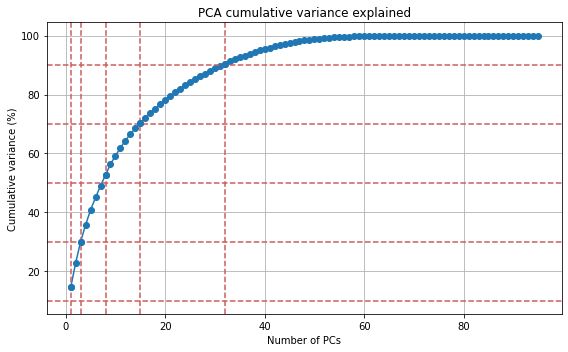

In [27]:
X = df_scd.copy()                   # death_label 없음
X_np = X.to_numpy(dtype=float)
n, d = X_np.shape
kmax = min(n, d)

pca = PCA(n_components=kmax, svd_solver='full', random_state=0)
pca.fit(X_np)

ratio = np.asarray(pca.explained_variance_ratio_, dtype=float)
ratio = ratio[np.isfinite(ratio)]
cum = np.cumsum(ratio)

def k_for(th):
    i = int(np.argmax(cum >= th))
    return i+1, float(cum[i])

k10, c10 = k_for(0.10); k30, c30 = k_for(0.30)
print(f"10% → {k10} PCs ({c10*100:.2f}%)")
print(f"30% → {k30} PCs ({c30*100:.2f}%)")
k50, c50 = k_for(0.50); k70, c70 = k_for(0.70); k90, c90 = k_for(0.90)
print(f"50% → {k50} PCs ({c50*100:.2f}%)")
print(f"70% → {k70} PCs ({c70*100:.2f}%)")
print(f"90% → {k90} PCs ({c90*100:.2f}%)")

Z = pca.transform(X_np)  # (n, kmax)

def make_reduced_df(Z, k_keep, index):
    return pd.DataFrame(Z[:, :k_keep], index=index,
                        columns=[f"PC{i+1}" for i in range(k_keep)])

df_pc10 = make_reduced_df(Z, k10, X.index)
df_pc30 = make_reduced_df(Z, k30, X.index)
df_pc50 = make_reduced_df(Z, k50, X.index)
df_pc70 = make_reduced_df(Z, k70, X.index)
df_pc90 = make_reduced_df(Z, k90, X.index)

# Save files
# df_pc10.to_csv(os.path.join(Z_dir, f"PCs_10pct_{k10}.csv"))
# df_pc30.to_csv(os.path.join(Z_dir, f"PCs_30pct_{k30}.csv"))
# df_pc50.to_csv(os.path.join(Z_dir, f"PCs_50pct_{k50}.csv"))
# df_pc70.to_csv(os.path.join(Z_dir, f"PCs_70pct_{k70}.csv"))
# df_pc90.to_csv(os.path.join(Z_dir, f"PCs_90pct_{k90}.csv"))

# print("CSV files saved in:", Z_dir)

# Plotting
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum)+1), cum*100, marker='o', label="Cumulative variance")
for h in (10, 30, 50, 70, 90): plt.axhline(h, linestyle='--', color='#CD5C5C')
for vv in (k10, k30, k50, k70, k90): plt.axvline(vv, linestyle='--', color='#CD5C5C')
plt.scatter([k10, k30, k50, k70, k90],
            [c10*100, c30*100, c50*100, c70*100, c90*100], zorder=5)
plt.title("PCA cumulative variance explained")
plt.xlabel("Number of PCs"); plt.ylabel("Cumulative variance (%)")
plt.grid(True); plt.tight_layout()
# plt.savefig(os.path.join(Z_dir, "ppca_cumvar.png"), dpi=150)
plt.show()

In [223]:
## PC-Loadings

dim = 15
X = df_scd.values.astype(float)
n, d = X.shape
dim = min(dim, n, d)  # 안전하게 보정

pca = PCA(n_components=dim, svd_solver='full', random_state=0)
pca.fit(X)

# feature × PC 로딩 (unit loadings)
components = [f'PC{i+1}' for i in range(dim)]
pca_loadings = pd.DataFrame(
    pca.components_.T,              # (n_features, dim)
    index=df_scd.columns,
    columns=components
)

# 1) 각 PC에서 |loading| 기준 정렬
ranked = {
    pc: pca_loadings[pc].abs().sort_values(ascending=False).index
    for pc in components
}

# 2) 집계용 딕셔너리 → 하나의 DataFrame
n_feat = len(df_scd.columns)
table = {'Sorted Index': range(1, n_feat + 1)}
for pc in components:
    feats = ranked[pc]
    loads = pca_loadings.loc[feats, pc].values
    table[f'{pc} : Feature name'] = feats
    table[f'{pc} : PC Loading']   = loads

combined_df = pd.DataFrame(table).set_index('Sorted Index')

# EN 매핑
mapping_path = os.path.join(base, "Dataset")
mapping_fp   = os.path.join(mapping_path, "spc_ColumnDescription+imputation_M02.xlsx")

df_dic_raw = pd.read_excel(mapping_fp)[['column','eCRF','col_KR']].copy()
for c in ['column','eCRF','col_KR']:
    df_dic_raw[c] = df_dic_raw[c].astype('string').str.strip()

df_dic_feat = (df_dic_raw
               .dropna(subset=['column'])
               .groupby('column', as_index=False)
               .agg({'eCRF':'first','col_KR':'first'}))

map_feat  = dict(zip(df_dic_feat['column'], df_dic_feat['col_KR']))
map_ecrf  = dict(zip(df_dic_feat['column'], df_dic_feat['eCRF']))

# 각 PC에 대해 붙이기 (컬럼명: Feature_KOR)
for pc in components:  # e.g., ['PC1','PC2',...]
    src_col = f'{pc} : Feature name'
    combined_df[f'{pc} : eCRF']        = combined_df[src_col].map(map_ecrf).fillna('')
    combined_df[f'{pc} : Feature_KOR'] = combined_df[src_col].map(map_feat).fillna('')

# 총합 행(유지)
total_row = {col: '' for col in combined_df.columns}
for pc in components:
    total_row[f'{pc} : PC Loading'] = pca_loadings[pc].abs().sum()
combined_df.loc['PC Loading Summary'] = total_row

# 열 순서 정리
new_order = []
for pc in components:
    new_order += [
        f'{pc} : Feature name',
        f'{pc} : eCRF',
        f'{pc} : Feature_KOR',
        f'{pc} : PC Loading'
    ]
combined_df = combined_df[new_order]

# 4) 결과 확인
combined_df

,PC1 : Feature name,PC1 : eCRF,PC1 : Feature_KOR,PC1 : PC Loading,PC2 : Feature name,PC2 : eCRF,PC2 : Feature_KOR,PC2 : PC Loading,PC3 : Feature name,PC3 : eCRF,...,PC13 : Feature_KOR,PC13 : PC Loading,PC14 : Feature name,PC14 : eCRF,PC14 : Feature_KOR,PC14 : PC Loading,PC15 : Feature name,PC15 : eCRF,PC15 : Feature_KOR,PC15 : PC Loading
Sorted Index,,,,,,,,,,,,,,,,,,,,,
1,ventil_dur,,,0.444058,bbph,"임신, 분만, 신생아 정보",출생 1시간 이내 혈액 가스 pH,-0.426388,gran,Eligibility evaluation & Demographic,...,PDA - 치료안함,0.324505,inhg_0,질환 관련 정보(Ⅱ),뇌실 내 출혈(Grade)_Neg,0.553822,PDA_TRD,질환 관련 정보,PDA - 치료함,0.351398
2,iarvppd,질환 관련 정보(Ⅰ),침습적 인공호흡기 사용 기간,0.410739,bbbe,"임신, 분만, 신생아 정보",출생 1시간 이내 혈액 가스의 base excess,-0.396983,parn,Eligibility evaluation & Demographic,...,PDA - 치료함,-0.324233,inhg_1+,질환 관련 정보(Ⅱ),뇌실 내 출혈(Grade)_Grade 1+,-0.553822,pda_non-treatment,질환 관련 정보,PDA - 치료안함,-0.350508
3,invfpod,질환 관련 정보(Ⅲ),정맥영양 기간,0.331891,apgs5,"임신, 분만, 신생아 정보",5분 아프가 점수,-0.391742,mage,Eligibility evaluation & Demographic,...,저혈압 유무_Pos,-0.283945,strdu_0,질환 관련 정보(Ⅰ),기관지폐이형성(BPD) 예방 및 치료를 위한 steroid 사용 유무_Neg,0.213257,aoxyuppd,질환 관련 정보(Ⅰ),보조적 산소/유량 투여기간,0.285171
4,apgs5,"임신, 분만, 신생아 정보",5분 아프가 점수,-0.234886,apgs1,"임신, 분만, 신생아 정보",1분 아프가 점수,-0.379301,apgs5,"임신, 분만, 신생아 정보",...,저혈압 유무_Neg,0.283945,strdu_1,질환 관련 정보(Ⅰ),기관지폐이형성(BPD) 예방 및 치료를 위한 steroid 사용 유무_Pos,-0.213257,oxyt36_2,질환 관련 정보(Ⅰ),교정 연령 36주 시점 산소치료_30% 미만 산소,-0.262877
5,apgs1,"임신, 분만, 신생아 정보",1분 아프가 점수,-0.233500,parn,Eligibility evaluation & Demographic,출산력(Parity),0.295682,apgs1,"임신, 분만, 신생아 정보",...,보조적 산소/유량 투여기간,0.274305,iarvppd,질환 관련 정보(Ⅰ),침습적 인공호흡기 사용 기간,0.191281,delm_1,"임신, 분만, 신생아 정보",분만 방식_1=질식분만,0.220169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,bir2,"임신, 분만, 신생아 정보",다태아 중 출생 순서 2nd,0.000474,PPHN,질환 관련 정보,PPHN,0.000278,bpia_3,"임신, 분만, 신생아 정보",...,임신 중 양수량_과다증,-0.000721,bir2,"임신, 분만, 신생아 정보",다태아 중 출생 순서 2nd,-0.000510,amni_3,Eligibility evaluation & Demographic,임신 중 양수량_과다증,-0.004045
93,atbyn_0,"임신, 분만, 신생아 정보",산전 항생제 사용 여부_Neg,0.000151,bpia_3,"임신, 분만, 신생아 정보",출생 장소(Birth place)_병원 이외 장소,0.000263,pvl_2,질환 관련 정보(Ⅱ),...,PDA - Unknown,0.000352,resu_0,"임신, 분만, 신생아 정보",초기 소생술 필요 유무_Neg,0.000389,htn_3,"임신, 분만, 신생아 정보",고혈압(HTN)_Chronic HTN,-0.001680
94,pda_unknown,질환 관련 정보,PDA - Unknown,0.000094,bpia_1,"임신, 분만, 신생아 정보",출생 장소(Birth place)_원내,-0.000176,pvl_1,질환 관련 정보(Ⅱ),...,폐표면활성제 사용 유무_Neg,-0.000097,bir3,"임신, 분만, 신생아 정보",다태아 중 출생 순서 3rd,0.000377,bpia_3,"임신, 분만, 신생아 정보",출생 장소(Birth place)_병원 이외 장소,0.001677


In [224]:
combined_df.to_excel(os.path.join(Z_dir, f"PCLoadings_{dim}PCs.xlsx")
                     , sheet_name="PC Loadings", index=True)

In [14]:
'''
## PPCA


X = df_scd.copy()
y = X.pop("death_label") if "death_label" in X.columns else None

X_np = X.to_numpy()
n, d = X_np.shape
k = max(1, min(n, d) - 1)

pp = PPCA()
pp.fit(X_np, d=k)

eig = np.asarray(pp.eig_vals, dtype=float)
eig = eig[np.isfinite(eig)]
ratio = eig / eig.sum()
cum = np.cumsum(ratio)

def k_for(th):
    i = int(np.argmax(cum >= th))
    return i+1, float(cum[i])


k10, c10 = k_for(0.10)
k30, c30 = k_for(0.30)
print(f"10% → {k10} PCs ({c10*100:.2f}%)")
print(f"30% → {k30} PCs ({c30*100:.2f}%)")

k50, c50 = k_for(0.50)
k70, c70 = k_for(0.70)
k90, c90 = k_for(0.90)
print(f"50% → {k50} PCs ({c50*100:.2f}%)")
print(f"70% → {k70} PCs ({c70*100:.2f}%)")
print(f"90% → {k90} PCs ({c90*100:.2f}%)")

# ** mean 대치 없이, 관측치만으로 Z 계산
W  = np.asarray(pp.C, dtype=float)            # (d, k) loadings
mu = np.asarray(pp.means, dtype=float)        # (d,)
Z  = np.full((n, W.shape[1]), np.nan, float)  # (n, k)

ridge = 1e-6  # 수치 안정화(필요 시 1e-5~1e-4로 조정)
Ik = np.eye(W.shape[1])

for i in range(n):
    obs = ~np.isnan(X_np[i])
    if not np.any(obs):
        continue  # 전부 NaN이면 그대로 NaN (표식으로 남김)
    Wi = W[obs, :]                         # (d_obs, k)
    xi = X_np[i, obs] - mu[obs]            # (d_obs,)
    M  = Wi.T @ Wi
    b  = Wi.T @ xi
    try:
        Z[i, :] = np.linalg.solve(M + ridge*Ik, b)
    except np.linalg.LinAlgError:
        Z[i, :] = np.linalg.lstsq(M + ridge*Ik, b, rcond=None)[0]

# 축소 DF 생성/저장/플롯
def make_reduced_df(Z, k_keep, index, y=None):
    df_red = pd.DataFrame(Z[:, :k_keep], index=index,
                          columns=[f"PC{i+1}" for i in range(k_keep)])
    if y is not None:
        df_red.insert(0, "death_label", y.values)
    return df_red

df_pc10 = make_reduced_df(Z, k10, X.index, y)
df_pc30 = make_reduced_df(Z, k30, X.index, y)
df_pc50 = make_reduced_df(Z, k50, X.index, y)
df_pc70 = make_reduced_df(Z, k70, X.index, y)
df_pc90 = make_reduced_df(Z, k90, X.index, y)

# os.makedirs(out, exist_ok=True)
# df_pc10.to_csv(os.path.join(out, f"PCs_10pct_{k10}.csv"))
# df_pc30.to_csv(os.path.join(out, f"PCs_30pct_{k30}.csv"))

# df_pc50.to_csv(os.path.join(out, f"PCs_50pct_{k50}.csv"))
# df_pc70.to_csv(os.path.join(out, f"PCs_70pct_{k70}.csv"))
# df_pc90.to_csv(os.path.join(out, f"PCs_90pct_{k90}.csv"))
print("CSV files saved in:", out)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum)+1), cum*100, marker='o', label="Cumulative variance")
for h in (10, 30, 50, 70, 90): plt.axhline(h, linestyle='--', color='#CD5C5C')
for vv in (k10, k30, k50, k70, k90): plt.axvline(vv, linestyle='--', color='#CD5C5C')
plt.scatter([k10, k30, k50, k70, k90]
            , [c10*100, c30*100, c50*100, c70*100, c90*100]
            , zorder=5)
plt.title("PPCA cumulative variance explained")
plt.xlabel("Number of PCs"); plt.ylabel("Cumulative variance (%)")
plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(out, "ppca_cumvar.png"), dpi=150)
plt.close()
'''

10% → 1 PCs (11.03%)
30% → 6 PCs (32.80%)
50% → 13 PCs (50.96%)
70% → 23 PCs (70.75%)
90% → 38 PCs (90.58%)
CSV files saved in: /media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp


In [225]:
df_pc30

,PC1,PC2,PC3
pid,,,
1,0.175825,-0.261276,-0.628978
4,-2.395263,0.868456,1.291025
15,0.636534,0.230721,-1.100559
43,1.048750,1.263837,2.290182
44,-0.808903,1.038259,-1.783501
...,...,...,...
16310,0.348853,0.768345,-0.214614
16312,1.665278,5.193040,7.130076
16318,-0.332424,2.226751,-0.209870


In [390]:
# save_dir = f'{out}/withPCA/PCA30'
save_dir = out
df_scd = df_pc70.copy()

In [391]:
df_scd

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
pid,,,,,,,,,,,,,,,
1,0.637472,-0.192032,-0.653750,-0.690621,0.118026,-0.574696,0.398800,-0.023918,-0.924535,-0.715277,-1.022365,-0.099171,0.275468,-0.500648,-1.010404
4,-2.167211,0.731765,1.206133,-0.451206,-1.091257,0.510959,0.885854,0.527760,-1.033946,0.414011,-0.288244,-0.709626,0.533225,-0.621119,0.105423
15,1.113771,0.295754,-1.204269,-1.055093,1.156160,-0.441707,0.233958,1.459025,-1.421152,-0.716135,-0.165792,-0.104353,-0.734145,0.545958,0.456160
44,-0.492647,1.096670,-1.682809,1.044178,-1.446847,0.359240,-0.006322,-1.227278,0.879336,0.037179,-0.724846,-0.703019,0.951014,0.879613,-0.102010
50,-0.075191,0.416647,1.342692,-0.302243,1.756297,-0.277287,-0.376711,-0.478233,-0.396335,-0.676353,0.161002,-1.013801,-0.655308,0.721338,0.364609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16303,3.423588,-1.796390,1.445607,1.764567,-2.018986,-1.904801,0.298867,1.581996,-0.897616,2.003457,1.318553,-0.328147,0.016479,-0.724086,0.304678
16304,-0.660057,0.040521,-1.892089,0.222041,0.052216,1.509913,-0.688950,-0.176210,-0.102446,0.684208,1.385522,0.084408,0.176171,-0.051215,0.498790
16305,0.975127,-0.824062,-1.135629,0.634289,-0.258879,0.442254,-0.210343,1.003023,-0.494648,-0.458807,1.519544,-0.208460,-1.066002,0.603667,-0.531642


In [403]:
# non-PCA
save_dir = out

In [32]:
## WCSS_scores (MiniBatch K-means)

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f57506fa3a0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f57485d2790>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f5dcc001dc0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f57485d2790>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f5dcbe4aee0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

...

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f5dcbe4aee0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f5dcc001dc0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f5dcbe4aee0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f5dcbe4aee0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f5dcc001dc0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn

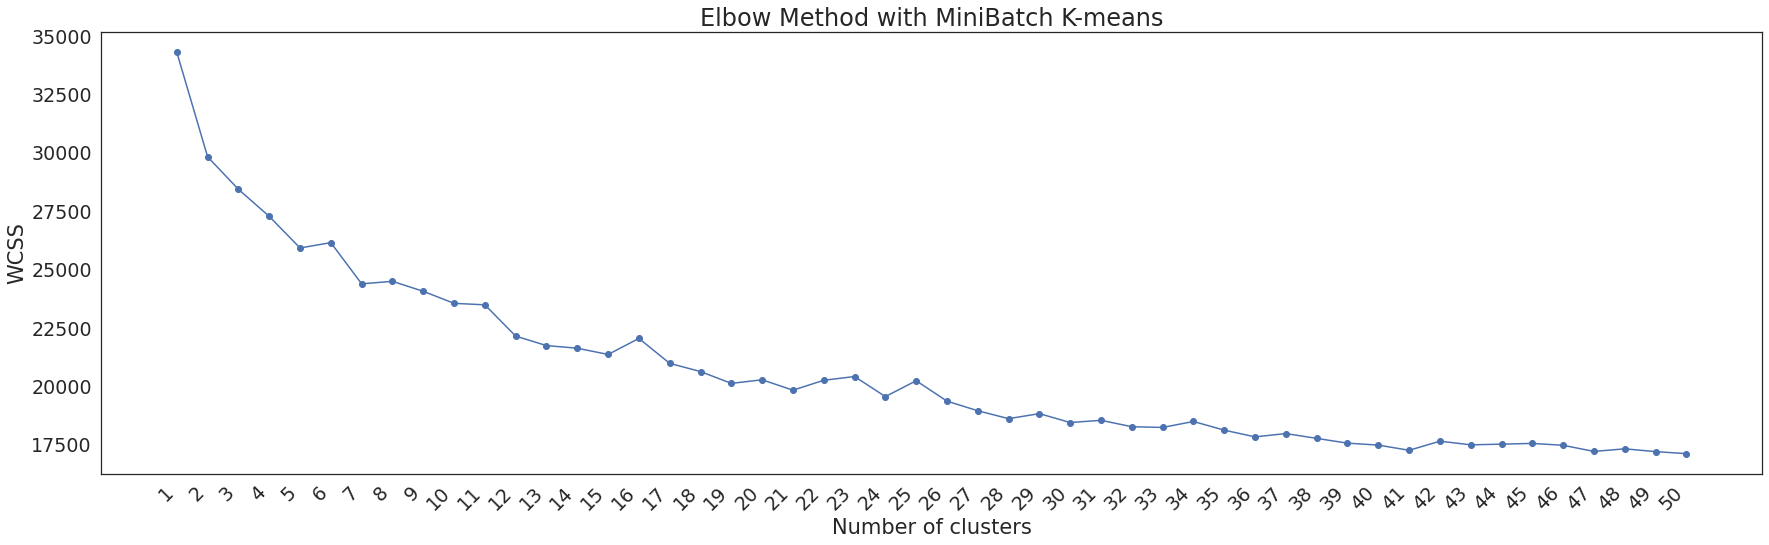

In [392]:
# df1 = pd.read_csv(os.path.join(data, "prep_origin_scd.csv"))
# df1 = df1.drop(columns=['Unnamed: 0'])


data = df_scd.copy()

# df_tmp = df_scd.copy()
# na_cols = df_tmp.isna().sum()
# na_cols = na_cols[na_cols > 0].sort_values(ascending=False)
# print("#### 결측값이 존재하는 컬럼:")
# print(na_cols)


# mean_survived = df_tmp.loc[df_tmp['death_label'] == 0, 'EFYN_day'].mean()
# mean_dead     = df_tmp.loc[df_tmp['death_label'] == 1, 'EFYN_day'].mean()
# mean_avg = (mean_survived + mean_dead) / 2
# df_tmp['EFYN_day'] = df_tmp['EFYN_day'].fillna(mean_avg)

# data_for_clustering = df_tmp.drop(columns=['death_label'])
# data = data_for_clustering

# Initialise list(WCSS)
wcss = []

# MiniBatch KMeans 클러스터링 실행 및 WCSS 계산
for i in range(1, 51):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=i, batch_size=100, random_state=SEED)
    minibatch_kmeans.fit(data)
    wcss.append(minibatch_kmeans.inertia_)

font_size = 21
plt.rcParams.update({
    'font.size': font_size
    , 'axes.titlesize': font_size + 3
    , 'axes.labelsize': font_size
    , 'xtick.labelsize': font_size - 2
    , 'ytick.labelsize': font_size - 2
    , 'legend.fontsize': font_size - 2
})

# 그래프 생성
plt.figure(figsize=(25, 8))
plt.plot(range(1, 51), wcss, marker='o')
plt.title('Elbow Method with MiniBatch K-means')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

# X축 레이블을 클러스터 수와 WCSS 값을 포함한 괄호 형식으로 출력
x_labels = [f'{i}' for i, w in enumerate(wcss, 1)]    #  \n ({w:.2f}) for i, w in enumerate(wcss, 1)
plt.xticks(range(1, 51), x_labels, rotation=45, ha='right')  # 49도 회전 및 오른쪽 정렬

# 그래프 표시
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "WCSS_plot.png"))
plt.show()

In [393]:
wcss

[34310.7775632296,
 29830.656996355956,
 28439.10200299606,
 27280.74314834182,
 25926.63667352818,
 26155.15577534076,
 24390.634940342883,
 24497.98339576959,
 24070.36844525236,
 23555.315832739037,
 23491.06375699282,
 22151.98798838693,
 21745.23972010092,
 21633.17308503097,
 21365.025214251156,
 22052.31674049543,
 20983.433776120964,
 20632.556172619134,
 20126.367854664764,
 20279.609250992453,
 19835.415917697705,
 20258.95194194534,
 20420.26292529235,
 19560.18332543374,
 20239.5927428888,
 19365.870625522577,
 18953.76699891235,
 18615.66057874159,
 18830.088021636457,
 18449.414362168325,
 18544.79110538349,
 18270.872270222193,
 18239.081005860455,
 18495.136457526274,
 18122.20218941593,
 17835.609432687346,
 17977.033770881775,
 17770.65094748199,
 17566.466692384336,
 17482.777649672153,
 17260.41344971665,
 17651.01874065123,
 17494.179288686664,
 17523.242331294645,
 17555.23672772252,
 17474.848123991243,
 17211.71758736413,
 17322.89257426912,
 17203.65531903675,


In [33]:
# ## with PCA
# n_out = f'{out}/withPCA/PCA30/C27'
# # n_out = f'{out}/PCA70'
# # n_out = f'{out}/PCA90'
# save_dir = n_out

In [83]:
# CLUSTERING :: HIERARCHICAL

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'PC11', 'PC12', 'PC13', 'PC14', 'PC15'],
      dtype='object') 15
Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'PC11', 'PC12', 'PC13', 'PC14', 'PC15'],
      dtype='object') 15
Calculating Gower distance matrix...
Distance matrix calculation completed.
Performing hierarchical clustering...
Hierarchical clustering completed.
Calculating silhouette scores using precomputed Gower distance...
[n_clusters=2] Silhouette avg = 0.069, std_dev = 0.102
[n_clusters=3] Silhouette avg = 0.070, std_dev = 0.079
[n_clusters=4] Silhouette avg = 0.071, std_dev = 0.063
[n_clusters=5] Silhouette avg = 0.071, std_dev = 0.049
[n_clusters=6] Silhouette avg = 0.047, std_dev = 0.045
[n_clusters=7] Silhouette avg = 0.049, std_dev = 0.194
[n_clusters=8] Silhouette avg = 0.051, std_dev = 0.183
[n_clusters=9] Silhouette avg = 0.041, std_dev = 0.171
Best number of clusters based on STD DEVIAT

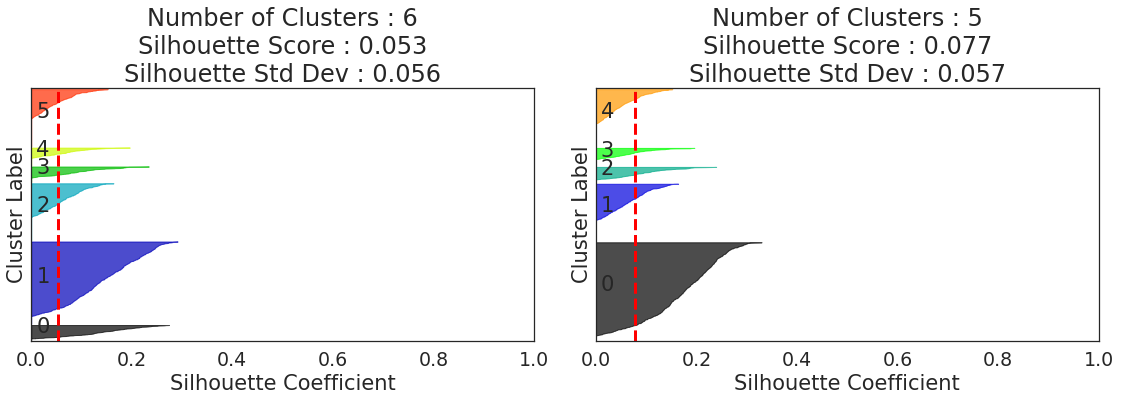

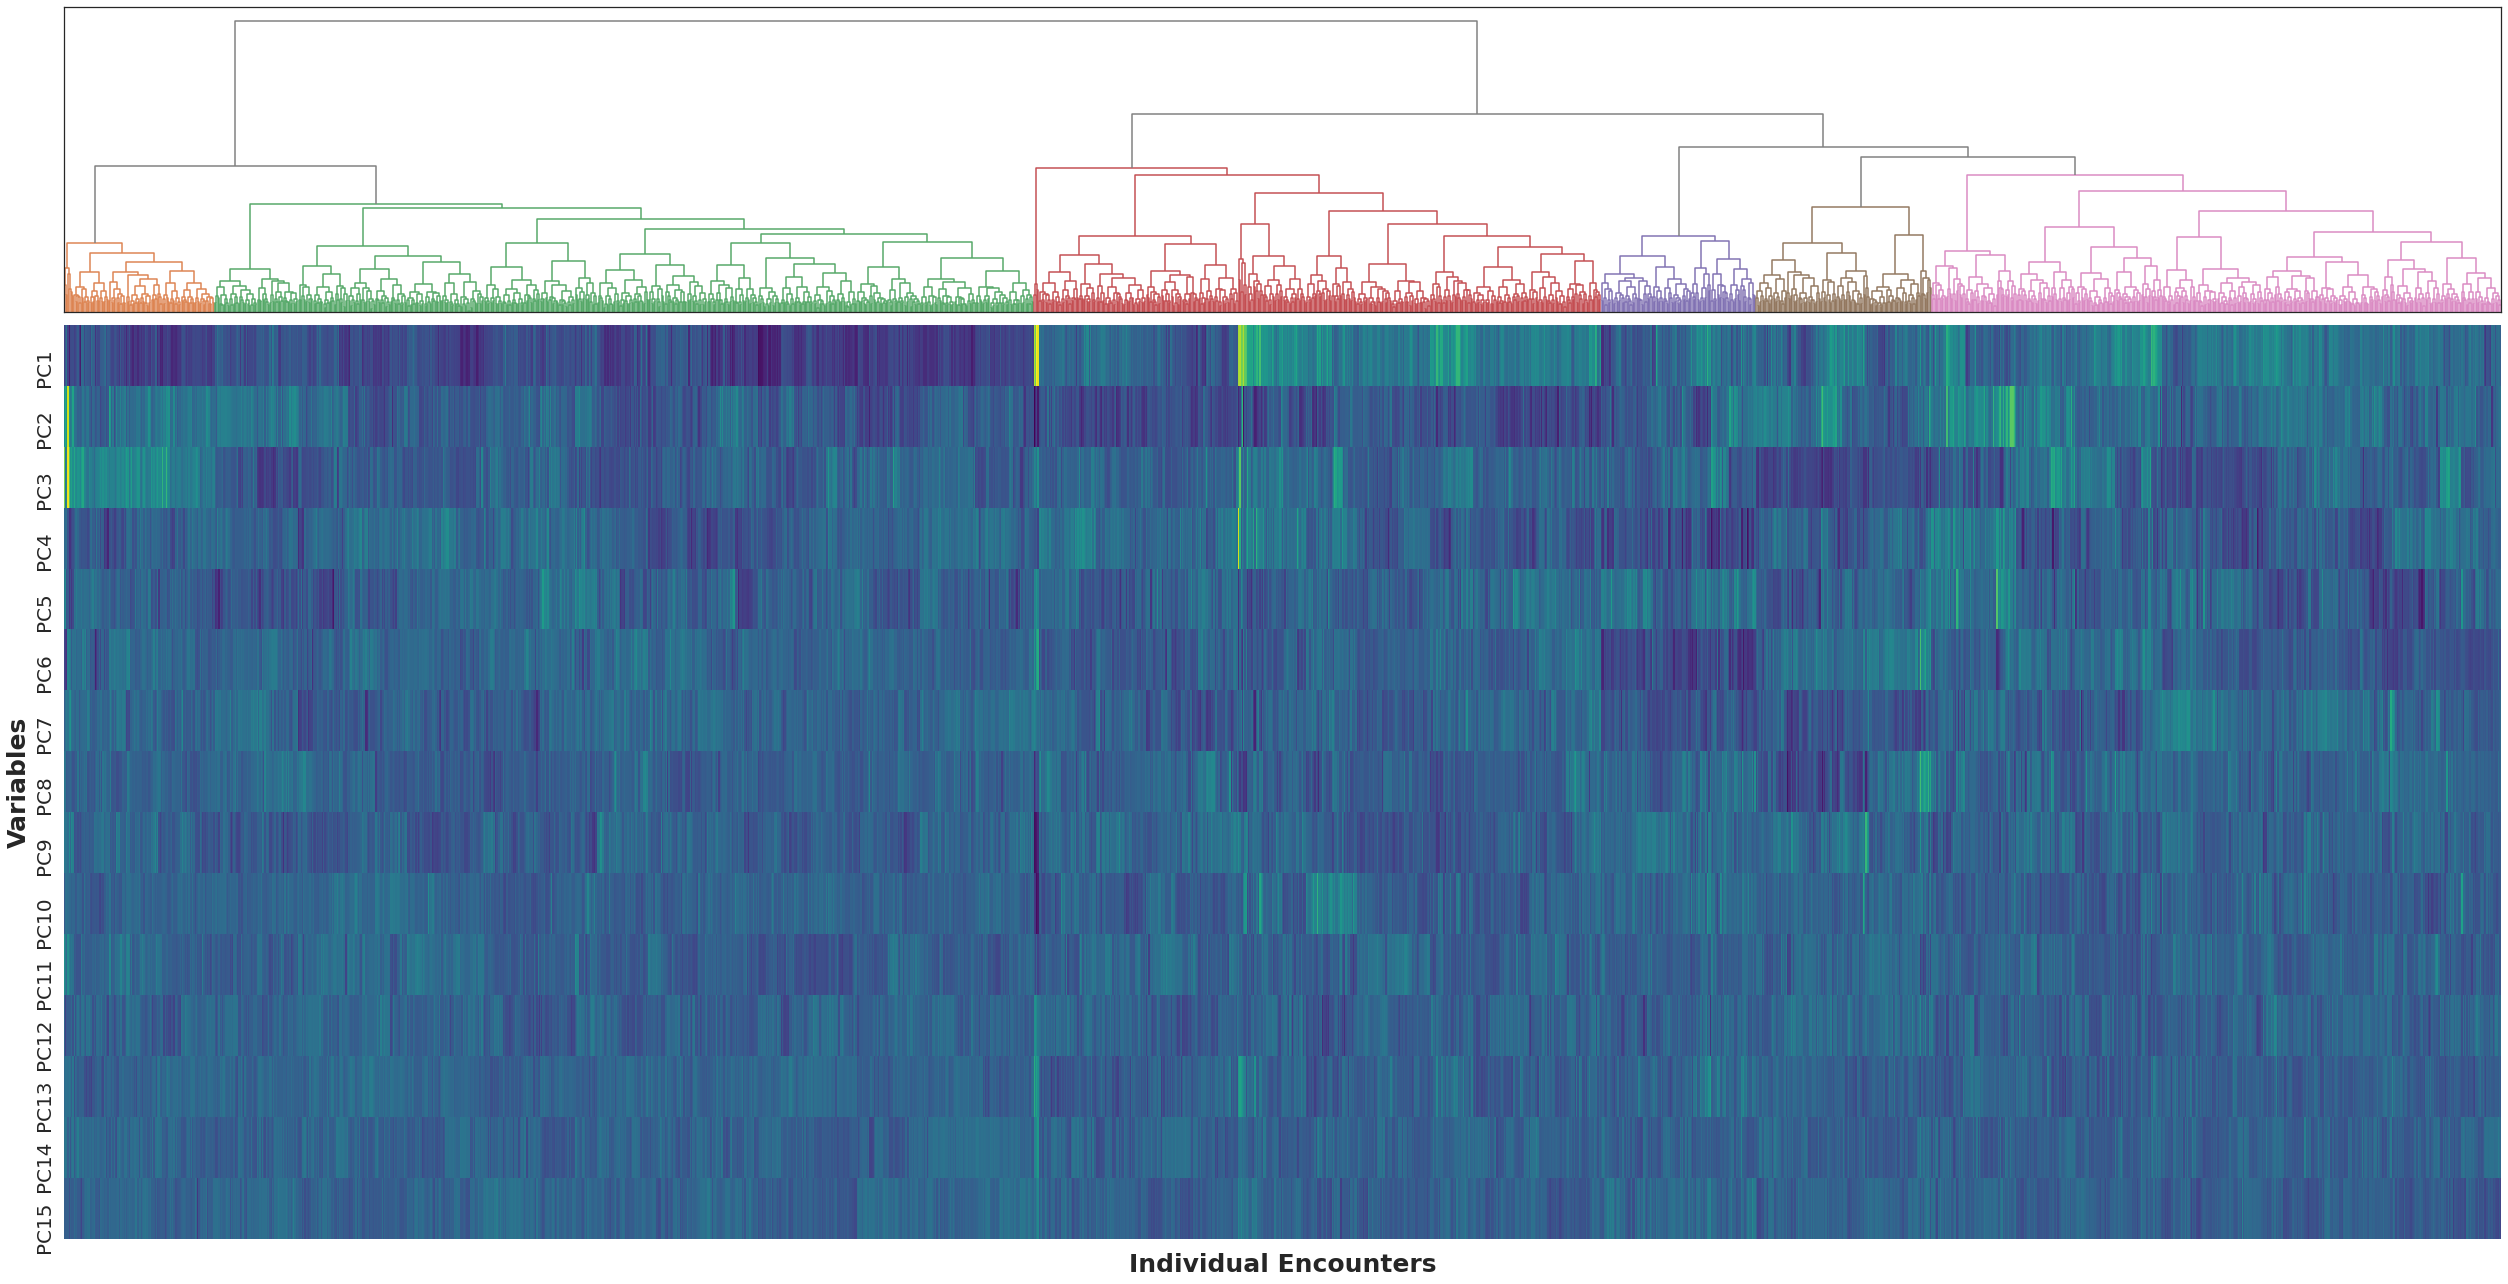

Dendrogram + Heatmap saved: path : /media/bami/JHA/24-07_nedis/KNN-ROP/Clustering/M03/PCA/GA25-27/PCA70/C/cluster_analysis_scd.png
Clustering completed with SCALED data.
            PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
pid                                                                           
1      0.637472 -0.192032 -0.653750 -0.690621  0.118026 -0.574696  0.398800   
4     -2.167211  0.731765  1.206133 -0.451206 -1.091257  0.510959  0.885854   
15     1.113771  0.295754 -1.204269 -1.055093  1.156160 -0.441707  0.233958   
44    -0.492647  1.096670 -1.682809  1.044178 -1.446847  0.359240 -0.006322   
50    -0.075191  0.416647  1.342692 -0.302243  1.756297 -0.277287 -0.376711   
...         ...       ...       ...       ...       ...       ...       ...   
16303  3.423588 -1.796390  1.445607  1.764567 -2.018986 -1.904801  0.298867   
16304 -0.660057  0.040521 -1.892089  0.222041  0.052216  1.509913 -0.688950   
16305  0.975127 -0.824062 -1.135629  0.6

In [394]:
# data_for_clustering = df_scd.drop(columns=['death_label'])
data_for_clustering = df_scd
print(df_scd.columns, len(df_scd.columns))
print(data_for_clustering.columns, len(data_for_clustering.columns))


# 사용자 정의 Gower 거리 계산 함수
def gower_distance_custom(X):
    """Custom Gower distance computation that ignores NaN values and does not normalize numerical differences."""
#     n_samples, n_features = X.shape
#     G = np.zeros((n_samples, n_samples))
    
#     for i in range(n_features):
#         feature = X[:, i]
#         if np.issubdtype(feature.dtype, np.number):
#             # 수치형 피쳐: 정규화 없이 절대 차이 사용
#             diff_matrix = np.abs(feature - feature.reshape(-1, 1))
#             diff_matrix[np.isnan(diff_matrix)] = 0  # NaN은 무시
#             G += diff_matrix
#         else:
#             # 범주형 피쳐: 동일하지 않으면 1, 동일하면 0
#             feature = feature.astype(str)
#             diff_matrix = (feature != feature.reshape(-1, 1)).astype(float)
#             diff_matrix[np.isnan(diff_matrix)] = 0  # NaN은 무시
#             G += diff_matrix
    
#     # 피쳐 수로 나누어 평균을 구함
#     G /= n_features
#     return G
    n_samples, n_features = X.shape
    
    # G[row, col]: 샘플 row와 col 간 '거리 합'
    G = np.zeros((n_samples, n_samples), dtype=float)
    # valid[row, col]: 결측 없이 비교가 가능한(둘 다 관측된) 변수 개수
    valid = np.zeros((n_samples, n_samples), dtype=float)
    
    for feat_idx in range(n_features):
        col_data = X[:, feat_idx]
        
        # 수치형 변수인지 판별
        if np.issubdtype(col_data.dtype, np.number):
            # 결측 여부
            not_nan_mask = ~np.isnan(col_data)
            
            for row in range(n_samples):
                for col in range(row + 1, n_samples):
                    # 둘 다 관측된 경우에만 거리 계산
                    if not_nan_mask[row] and not_nan_mask[col]:
                        dist_val = abs(col_data[row] - col_data[col])
                        G[row, col] += dist_val
                        G[col, row] += dist_val
                        valid[row, col] += 1
                        valid[col, row] += 1
                        
        else:
            # 범주형 변환 (NaN 처리 위해 object로)
            col_str = col_data.astype('O')  
            # non-null 마스크
            not_nan_mask = pd.notna(col_str)
            
            for row in range(n_samples):
                for col in range(row + 1, n_samples):
                    if not_nan_mask[row] and not_nan_mask[col]:
                        # 둘 다 관측이면
                        dist_val = 0.0 if col_str[row] == col_str[col] else 1.0
                        G[row, col] += dist_val
                        G[col, row] += dist_val
                        valid[row, col] += 1
                        valid[col, row] += 1
    
    # 유효 변수만큼 나누어 평균화
    for row in range(n_samples):
        for col in range(n_samples):
            if valid[row, col] > 0:
                G[row, col] /= valid[row, col]
            else:
                # valid=0인 경우, 둘 다 모든 변수 결측 -> 거리=0 (또는 np.nan)
                G[row, col] = 0.0
    
    return G

# 클러스터링 데이터를 넘파이 배열로 변환
X = data_for_clustering.to_numpy()

# 사용자 정의 Gower 거리 계산
print("Calculating Gower distance matrix...")
distance_matrix = gower_distance_custom(X)
print("Distance matrix calculation completed.")

# Condensed 거리 행렬 생성
distance_matrix_condensed = squareform(distance_matrix)  # 비대각 성분만 추출

# 계층적 클러스터링 수행
print("Performing hierarchical clustering...")
# Z_objects = linkage(distance_matrix_condensed, method='ward')
Z_objects = linkage(distance_matrix_condensed, method='ward')    # Ward method applied
print("Hierarchical clustering completed.")

# Z_objects를 저장
with open(os.path.join(save_dir, "Z_objects.pkl"), "wb") as f:
    pickle.dump(Z_objects, f)

# 실루엣 점수 및 표준 편차 계산
print("Calculating silhouette scores using precomputed Gower distance...")
silhouette_scores = []
silhouette_std_devs = []
range_n_clusters = list(range(2, 10))

for n_clusters in range_n_clusters:
    # 군집 레이블
    cluster_labels = fcluster(Z_objects, t=n_clusters, criterion='maxclust')
    
    # silhouette_samples() 호출 시 metric='precomputed' -> X가 '거리 행렬'이어야 함
    # distance_matrix: (n_samples x n_samples) 형태
    sil_values = silhouette_samples(distance_matrix, cluster_labels, metric='precomputed')
    sil_avg = np.mean(sil_values)
    
    # 각 클러스터별 평균을 구한 뒤 표준편차 계산
    cluster_means = []
    for label in np.unique(cluster_labels):
        cluster_means.append(np.mean(sil_values[cluster_labels == label]))
    sil_std_dev = np.std(cluster_means)
    
    silhouette_scores.append(sil_avg)
    silhouette_std_devs.append(sil_std_dev)
    
    print(f"[n_clusters={n_clusters}] Silhouette avg = {sil_avg:.3f}, std_dev = {sil_std_dev:.3f}")

best_n_clusters = range_n_clusters[np.argmin(silhouette_std_devs)]
highest_silhouette_clusters = range_n_clusters[np.argmax(silhouette_scores)]

# 편차가 가장 작은 클러스터 수 찾기
best_n_clusters = range_n_clusters[np.argmin(silhouette_std_devs)]
print("Best number of clusters based on STD DEVIATION:", best_n_clusters)
highest_silhouette_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print("Cluster number of the HIGHEST silhouette score:", highest_silhouette_clusters)
print()


def visualize_silhouette_for_best_and_highest(best_n_clusters, highest_silhouette_clusters, X_features, data):
    cluster_lists = [best_n_clusters, highest_silhouette_clusters]
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(8 * n_cols, 6), nrows=1, ncols=n_cols)
    
    for ind, n_cluster in enumerate(cluster_lists):
        cluster_labels = fcluster(Z_objects, t=n_cluster, criterion='maxclust')
        
        # NaN이 있는 샘플을 제외한 실루엣 점수 계산
        valid_idx = np.isfinite(X_features).all(axis=1)  # NaN이 없는 샘플 인덱스 추출
        X_valid = X_features[valid_idx]
        cluster_labels_valid = cluster_labels[valid_idx]
        
        # 유효한 샘플이 충분한지 확인
        if len(X_valid) == 0 or len(np.unique(cluster_labels_valid)) <= 1:
            print(f"Skipping silhouette calculation for n_clusters = {n_cluster} due to insufficient valid samples.")
            axs[ind].set_title(f"Number of Clusters : {n_cluster}\nNot enough valid data for silhouette")
            axs[ind].axis('off')  # 차트를 표시하지 않음
            continue
        
        sil_avg = silhouette_score(X_valid, cluster_labels_valid)
        sil_values = silhouette_samples(X_valid, cluster_labels_valid)
        sil_std_dev = np.std([np.mean(sil_values[cluster_labels_valid == label]) for label in np.unique(cluster_labels_valid)])
        
        y_lower = 10
        axs[ind].set_title(f'Number of Clusters : {n_cluster}\nSilhouette Score : {round(sil_avg, 3)}\nSilhouette Std Dev : {round(sil_std_dev, 3)}')
        axs[ind].set_xlabel("Silhouette Coefficient")
        axs[ind].set_ylabel("Cluster Label")
        axs[ind].set_xlim([0, 1])  # Silhouette score is always between -1 and 1; set lower bound to 0 to remove negative values.
        axs[ind].set_ylim([0, len(X_valid) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the y-axis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels_valid == i + 1]
            ith_cluster_sil_values.sort()
            
            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                                   facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(0.01, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
            
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--", linewidth=3)
        
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "visualize_silhouette_best_and_highest.png"))
    plt.show()

# 실루엣 스코어 시각화 및 저장
visualize_silhouette_for_best_and_highest(best_n_clusters
                                          , highest_silhouette_clusters
                                          , df_scd.to_numpy()
                                          , data
                                         )


# 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# Dendrogram
threshold = Z_objects[-(best_n_clusters - 1), 2]
dendrogram(Z_objects
           , ax=ax1
           , orientation='top'
           , color_threshold=threshold
           , above_threshold_color='grey'
          )
ax1.set_xticks([])
ax1.set_yticks([])

sorted_idx = dendrogram(Z_objects, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]

# Heatmap
sns.heatmap(data_sorted.T, ax=ax2, cbar=False, cmap='viridis', yticklabels=True)
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=20)
plt.tight_layout()

plt.savefig(os.path.join(save_dir, "cluster_analysis_scd.png"))
plt.show()

plt.close(fig)
print(f"Dendrogram + Heatmap saved: path : {save_dir}/cluster_analysis_scd.png")

# 클러스터 라벨을 데이터프레임에 추가
cluster_labels = fcluster(Z_objects, t=best_n_clusters, criterion='maxclust')
df_scd['Cluster_Labels'] = cluster_labels

# # 원래 index였던 pid를 다시 붙이기
# df_scd['pid'] = df.index
# df_scd.set_index('pid', inplace=True)

# df_scd['death_label'] = df['death_label']

# df_scd['Cluster_Labels_orn'] = original_cluster_labels    # 특정 클러스터를 사용하는 경우 사용

# 결과 출력
print("Clustering completed with SCALED data.")
print(df_scd)

In [47]:
Z_dir_ = f'{Z_dir}/'

In [243]:
df_scd

,PC1,PC2,PC3,Cluster_Labels
pid,,,,
1,0.175825,-0.261276,-0.628978,2
4,-2.395263,0.868456,1.291025,2
15,0.636534,0.230721,-1.100559,1
43,1.048750,1.263837,2.290182,2
44,-0.808903,1.038259,-1.783501,2
...,...,...,...,...
16310,0.348853,0.768345,-0.214614,1
16312,1.665278,5.193040,7.130076,2
16318,-0.332424,2.226751,-0.209870,2


n_clusters = 5: Cluster sizes = {1: 778, 2: 455, 3: 124, 4: 141, 5: 457}
For n_clusters = 5,
Average Silhouette_score : 0.0773,
std deviation: 0.0574



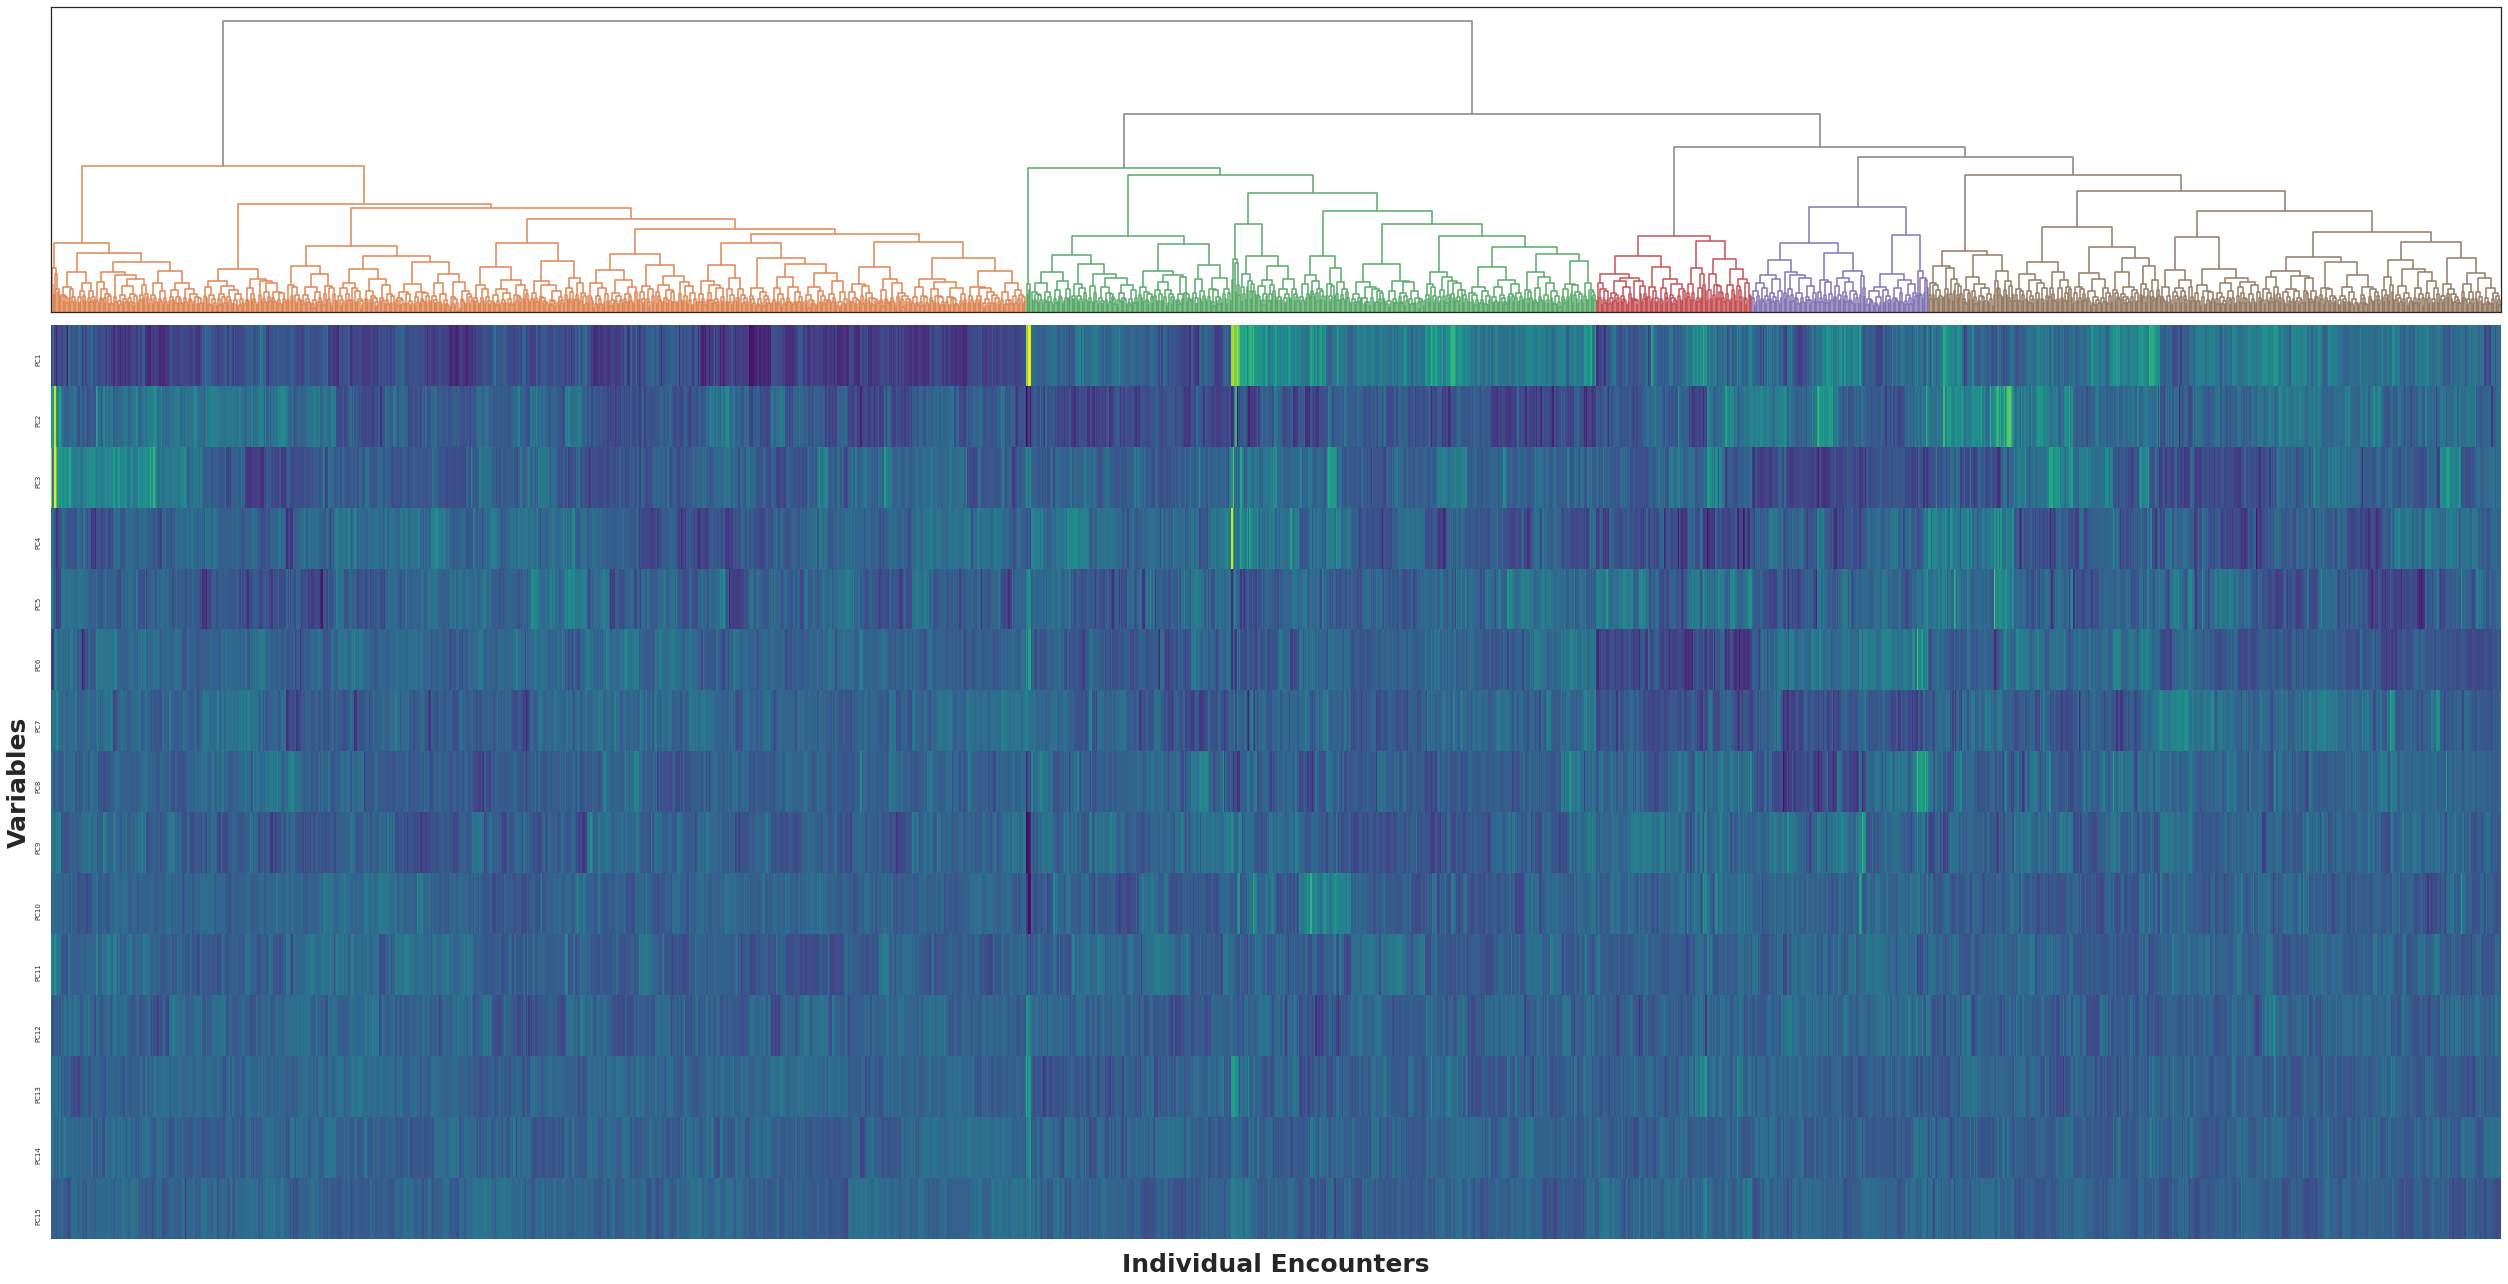

Dendrogram + Heatmap saved: path : /media/bami/JHA/24-07_nedis/KNN-ROP/Clustering/M03/PCA/GA25-27/PCA70/C5/cluster_analysis_scd.png
Clustering completed with 3 clusters.
            PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
pid                                                                           
1      0.637472 -0.192032 -0.653750 -0.690621  0.118026 -0.574696  0.398800   
4     -2.167211  0.731765  1.206133 -0.451206 -1.091257  0.510959  0.885854   
15     1.113771  0.295754 -1.204269 -1.055093  1.156160 -0.441707  0.233958   
44    -0.492647  1.096670 -1.682809  1.044178 -1.446847  0.359240 -0.006322   
50    -0.075191  0.416647  1.342692 -0.302243  1.756297 -0.277287 -0.376711   
...         ...       ...       ...       ...       ...       ...       ...   
16303  3.423588 -1.796390  1.445607  1.764567 -2.018986 -1.904801  0.298867   
16304 -0.660057  0.040521 -1.892089  0.222041  0.052216  1.509913 -0.688950   
16305  0.975127 -0.824062 -1.135629  0.6

In [404]:
## 재 클러스터링 with Z_objects : {n} Clusters

n_clusters = 5


# Z_objects 불러오기
# with open(os.path.join(Z_dir_, "Z_objects.pkl"), "rb") as f:
with open(os.path.join(Z_dir, "Z_objects.pkl"), "rb") as f:
    Z_objects = pickle.load(f)

# 데이터프레임에서 death_label 칼럼 제외
# data_for_clustering = df_scd.drop(columns=['death_label'])
data_for_clustering = df_scd.drop(columns=['Cluster_Labels'])

cluster_labels = fcluster(Z_objects, t=n_clusters, criterion='maxclust')

# 각 클러스터에 할당된 샘플 수 확인
unique, counts = np.unique(cluster_labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print(f"n_clusters = {n_clusters}: Cluster sizes = {cluster_counts}")

# 실루엣 점수 계산
silhouette_vals = silhouette_samples(data_for_clustering.fillna(0), cluster_labels)  # 개별 샘플의 실루엣 점수 계산
silhouette_avg = np.mean(silhouette_vals)  # 전체 실루엣 점수의 평균
silhouette_std_dev = np.std([np.mean(silhouette_vals[cluster_labels == label]) for label in np.unique(cluster_labels)])

# 실루엣 점수 및 표준 편차 출력
print(f"For n_clusters = {n_clusters},\nAverage Silhouette_score : {silhouette_avg:.4f},\nstd deviation: {silhouette_std_dev:.4f}\n")

# 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# Dendrogramme
threshold = Z_objects[-(n_clusters - 1), 2]
dendrogram(Z_objects
           , ax=ax1
           , orientation='top'
           , color_threshold=threshold
           , above_threshold_color='grey'
          )
ax1.set_xticks([])
ax1.set_yticks([])

sorted_idx = dendrogram(Z_objects, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]    ########

# Heatmap
sns.heatmap(data_sorted.T, ax=ax2, cbar=False, cmap='viridis', yticklabels=True)
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=7)
plt.tight_layout()

plt.savefig(os.path.join(save_dir, "cluster_analysis_scd.png"))
plt.show()

plt.close(fig)
print(f"Dendrogram + Heatmap saved: path : {save_dir}/cluster_analysis_scd.png")

# 클러스터 라벨을 데이터프레임에 추가
df_scd['Cluster_Labels'] = cluster_labels

# # 원래 index였던 pid를 다시 붙이기
# df_scd['pid'] = df.index
# df_scd.set_index('pid', inplace=True)

# df_scd['death_label'] = df['death_label']
# df_scd['Cluster_Labels_orn'] = original_cluster_labels    # 특정 클러스터를 사용하는 경우 사용

# 결과 출력
print("Clustering completed with 3 clusters.")
print(df_scd)

In [18]:
'''# {n} Level까지만 클러스터링
k_ = 2

data_for_clustering = df_scd.drop(columns=list(mortality))
print(df_scd.columns)
print(data_for_clustering.columns)

with open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:
    Z_objects = pickle.load(f)

# 2nd Level 결과추출
cluster_labels_level_2 = fcluster(Z_objects, t=k_, criterion='maxclust')
print("Cluster labels at level 2:", cluster_labels_level_2)

# Cluster_label 추가
df_scd['Cluster_Labels'] = cluster_labels_level_2
print("Clustering completed with SCALED data.")
print(df_scd[['Cluster_Labels']])

# 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# 계층적 클러스터링의 덴드로그램 그리기
# Z_objects 로드 (이전에 저장한 Z_objects.pkl을 사용하셨다면 해당 파일 로드 필요)
with open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:
    Z_objects = pickle.load(f)

# 2층 클러스터링 결과에 따른 threshold 계산
threshold = Z_objects[-2, 2]  # 2단계 클러스터링의 컷오프 높이 추출
dendrogram(Z_objects, ax=ax1, orientation='top', color_threshold=threshold, above_threshold_color='grey')
ax1.axhline(y=threshold, color='r', linestyle='--')  # 2층 분할 위치에 선 그리기
ax1.set_xticks([])
ax1.set_yticks([])

# 클러스터링 결과에 따른 데이터 정렬_
sorted_idx = dendrogram(Z_objects, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]  # 클러스터링 순서대로 데이터 정렬

# 히트맵 그리기
sns.heatmap(data_sorted.T, ax=ax2, cbar=False, cmap='viridis', yticklabels=True)
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=20)
plt.tight_layout()

# 결과 저장 및 보여주기
plt.savefig(os.path.join(save_dir, "0814_cluster_analysis_scd.png"))
plt.show()

plt.close(fig)
print(f"Dendrogram + Heatmap saved: path : {save_dir}/0814_cluster_analysis_scd.png")

# 결과 저장
df_scd.to_csv(os.path.join(save_dir, "df_scd_clustered_level_2.csv"))'''

'# {n} Level까지만 클러스터링\nk_ = 2\n\ndata_for_clustering = df_scd.drop(columns=list(mortality))\nprint(df_scd.columns)\nprint(data_for_clustering.columns)\n\nwith open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:\n    Z_objects = pickle.load(f)\n\n# 2nd Level 결과추출\ncluster_labels_level_2 = fcluster(Z_objects, t=k_, criterion=\'maxclust\')\nprint("Cluster labels at level 2:", cluster_labels_level_2)\n\n# Cluster_label 추가\ndf_scd[\'Cluster_Labels\'] = cluster_labels_level_2\nprint("Clustering completed with SCALED data.")\nprint(df_scd[[\'Cluster_Labels\']])\n\n# 시각화\nsns.set(style="white")\nfig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={\'height_ratios\': [1, 3]})\n\n# 계층적 클러스터링의 덴드로그램 그리기\n# Z_objects 로드 (이전에 저장한 Z_objects.pkl을 사용하셨다면 해당 파일 로드 필요)\nwith open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:\n    Z_objects = pickle.load(f)\n\n# 2층 클러스터링 결과에 따른 threshold 계산\nthreshold = Z_objects[-2, 2]  # 2단계 클러스터링의 컷오프 높이 추출\ndendrogram(Z_objects, ax=ax1, or

In [405]:
# df_scd.to_csv(os.path.join(out_0830, f"df\_scd_{best_n_clusters}clustered.csv"))
df_scd.to_csv(os.path.join(save_dir, f"df_scd_{n_clusters}clustered.csv"))

In [406]:
print(df_scd['Cluster_Labels'].value_counts().sort_index())
print(df_scd.isnull().sum())

1    778
2    455
3    124
4    141
5    457
Name: Cluster_Labels, dtype: int64
PC1               0
PC2               0
PC3               0
PC4               0
PC5               0
PC6               0
PC7               0
PC8               0
PC9               0
PC10              0
PC11              0
PC12              0
PC13              0
PC14              0
PC15              0
Cluster_Labels    0
dtype: int64


In [407]:
df_scd.to_csv(os.path.join(save_dir, "df_scd_clustered.csv"))

In [408]:
## Merge Cluster_Labels to original dataframe
df_combined = df.merge(df_scd[['Cluster_Labels']]
                       , left_index=True, right_index=True
                       , how='left'
                      )
df_combined

,sex_sys_val,birthdt,bir1,bir2,bir3,bir4,bird,admd,apgs1,apgs5,...,grwdd_m36,mendd,motdd,socdd,neudd,rop_severe,ventil_dur,oxyt28_Pos,oxyt36_Pos,Cluster_Labels
pid,,,,,,,,,,,,,,,,,,,,,
1,1,2013-11-15,0.0,0.0,0.0,0.0,2013-11-15,2013-11-15,4.0,5.0,...,0,0,0,0,0,0,66,1,1,2
4,1,2013-11-11,0.0,0.0,0.0,0.0,2013-11-11,2013-11-11,4.0,5.0,...,0,0,0,0,0,0,29,0,0,1
15,1,2013-06-10,0.0,0.0,0.0,0.0,2013-06-10,2013-06-10,4.0,5.0,...,0,0,1,0,1,0,59,1,1,5
44,1,2013-07-22,0.0,0.0,0.0,0.0,2013-07-22,2013-07-22,1.0,5.0,...,0,0,0,0,0,0,57,1,0,4
50,1,2013-11-11,0.0,0.0,0.0,0.0,2013-11-11,2013-11-11,6.0,8.0,...,0,0,0,0,0,0,57,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16303,1,2020-03-03,1.0,0.0,0.0,0.0,2020-03-03,2020-03-03,3.0,6.0,...,0,0,0,0,0,0,141,1,1,2
16304,0,2020-05-07,1.0,0.0,0.0,0.0,2020-05-07,2020-05-07,3.0,7.0,...,0,0,0,0,0,1,47,1,0,4
16305,1,2020-05-07,0.0,1.0,0.0,0.0,2020-05-07,2020-05-07,3.0,7.0,...,0,0,0,0,0,0,67,1,1,2


In [409]:
df_combined.to_csv(os.path.join(save_dir, "KNN-ROP_df_combined.csv"))

In [108]:
# WILCOXON TEST

# Declare input data
input_df = df_combined

# 고유 클러스터 값과 클러스터 수 계산
unique_clusters = input_df['Cluster_Labels'].unique()
num_clusters = len(unique_clusters)

# 통계 및 p-값 저장용 DataFrame 생성
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대한 계산
for i in unique_clusters:
    cluster_data = input_df[input_df['Cluster_Labels'] == i]
    outside_data = input_df[input_df['Cluster_Labels'] != i]
    stats = {}
    p_values = {}

    for column in input_df.columns[:-1]:  # 마지막 'Cluster_Labels' 제외
        if column != 'Cluster_Labels' and is_numeric_dtype(input_df[column]):
            valid_cluster_data = cluster_data[column].dropna()
            valid_outside_data = outside_data[column].dropna()

            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산
            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:
                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alternative='two-sided')
                mean_val = valid_cluster_data.mean()
                std_dev = valid_cluster_data.std()

                # 결과 저장
                stats[column] = f"{mean_val:.4f} ± {std_dev:.4f}"
                if p_value < 0.01:
                    formatted_p_value = f"{p_value:.4e}" if p_value < 0.0001 else f"{p_value:.4f}"
                    p_values[column] = formatted_p_value
                else:
                    p_values[column] = "n.s."
            else:
                stats[column] = "NaN ± NaN"
                p_values[column] = "n.s."

    stats_df[f'Cluster {i}'] = pd.Series(stats)
    p_values_df[f'Cluster {i}'] = pd.Series(p_values)

# 결과를 DataFrame으로 결합
combined_df = pd.DataFrame()
for i in unique_clusters:
    combined_stats = stats_df[f'Cluster {i}'] + " (" + p_values_df[f'Cluster {i}'] + ")"
    combined_df[f'Cluster {i}'] = combined_stats

# Cluster 열을 이름을 기준으로 정렬
combined_df = combined_df.reindex(sorted(combined_df.columns), axis=1)

# 결과 출력
print("Combined Mean, Standard Deviation and P-values:")
print(combined_df)

Combined Mean, Standard Deviation and P-values:
                                     Cluster 1  \
sex_sys_val       0.4632 ± 0.4987 (1.8092e-21)   
apgs1             5.9150 ± 1.7800 (0.0000e+00)   
apgs5             7.8937 ± 1.2993 (0.0000e+00)   
bwei         1290.1546 ± 200.2696 (0.0000e+00)   
mage                   33.4123 ± 4.3265 (n.s.)   
...                                        ...   
iperr_4                 0.0000 ± 0.0000 (n.s.)   
iperroy_1         0.9965 ± 0.0590 (1.5977e-51)   
iperroy_4         0.0004 ± 0.0190 (6.6493e-08)   
iperroy_3         0.0030 ± 0.0548 (1.4684e-40)   
iperroy_2         0.0001 ± 0.0110 (1.0079e-05)   

                                    Cluster 2  \
sex_sys_val      0.5474 ± 0.4979 (1.4545e-05)   
apgs1            2.8379 ± 1.7627 (0.0000e+00)   
apgs5            5.0526 ± 2.2205 (0.0000e+00)   
bwei         815.7654 ± 301.8103 (0.0000e+00)   
mage                  33.2194 ± 4.5537 (n.s.)   
...                                       ...   
iperr_4 

In [96]:
'''
# Wilcoxon test :: features --> P-Value 순으로 정렬

unique_clusters = df_combined['Cluster_Labels'].unique()

# 통계 및 p-값 저장용 DataFrame 생성
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대한 계산
for cluster in unique_clusters:
    cluster_data = df_combined[df_combined['Cluster_Labels'] == cluster]
    outside_data = df_combined[df_combined['Cluster_Labels'] != cluster]
    
    for column in df_combined.columns[:-1]:  # 마지막 'Cluster_Labels' 제외
        if column != 'Cluster_Labels' and is_numeric_dtype(df_combined[column]):
            valid_cluster_data = cluster_data[column].dropna()
            valid_outside_data = outside_data[column].dropna()

            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산
            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:
                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alternative='two-sided')
                mean_val = valid_cluster_data.mean()
                std_dev = valid_cluster_data.std()

                # 결과 저장
                stats_df.loc[column, f'Cluster {cluster}'] = f"{mean_val:.4f} ± {std_dev:.4f}"
                p_values_df.loc[column, f'Cluster {cluster}'] = p_value
            else:
                stats_df.loc[column, f'Cluster {cluster}'] = "NaN ± NaN"
                p_values_df.loc[column, f'Cluster {cluster}'] = float('nan')

# 각 특성별 최소 p-value 계산
p_values_df['min_p_value'] = p_values_df.min(axis=1)

# p-value를 기준으로 행 정렬
p_values_df = p_values_df.sort_values(by='min_p_value')

# 정렬된 순서대로 최종 DataFrame 구성
combined_df = pd.DataFrame()
for column in p_values_df.columns[:-1]:  # 'min_p_value' 제외
    formatted_values = stats_df[column].reindex(p_values_df.index).astype(str) + " (" + p_values_df[column].reindex(p_values_df.index).apply(lambda x: f"{x:.4e}" if x < 0.0001 else f"{x:.4f}" if x == x else "n.s.").astype(str) + ")"
    combined_df[column] = formatted_values

# 결과 출력
print("Combined Mean, Standard Deviation and P-values (sorted by feature min p-value):")
print(combined_df)
'''

'\n# Wilcoxon test :: features --> P-Value 순으로 정렬\n\nunique_clusters = df_combined[\'Cluster_Labels\'].unique()\n\n# 통계 및 p-값 저장용 DataFrame 생성\nstats_df = pd.DataFrame()\np_values_df = pd.DataFrame()\n\n# 각 클러스터 및 변수에 대한 계산\nfor cluster in unique_clusters:\n    cluster_data = df_combined[df_combined[\'Cluster_Labels\'] == cluster]\n    outside_data = df_combined[df_combined[\'Cluster_Labels\'] != cluster]\n    \n    for column in df_combined.columns[:-1]:  # 마지막 \'Cluster_Labels\' 제외\n        if column != \'Cluster_Labels\' and is_numeric_dtype(df_combined[column]):\n            valid_cluster_data = cluster_data[column].dropna()\n            valid_outside_data = outside_data[column].dropna()\n\n            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산\n            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:\n                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alter

In [57]:
combined_df.to_csv(os.path.join(save_dir, "KNN_df_combined_wilcoxon+p_val.csv")
                   , encoding='utf-8-sig'    # '±'표현을 위해 encoding='utf-8-sig' 사용
                  )

NameError: name 'combined_df' is not defined

In [410]:
## DEATH RATIO
# 'Cluster_Labels'와 'death_label' 확인
def calculate_positive_rate(ipt_df, ipt_col):
    # 'Cluster_Labels'와 ipt_col 확인
    if 'Cluster_Labels' in ipt_df.columns and ipt_col in ipt_df.columns:
        results_df = pd.DataFrame()

        # 각 클러스터의 Positive Rate 계산
        for i in sorted(ipt_df['Cluster_Labels'].unique()):  # Cluster_Labels 번호 순서대로 정렬
            cluster_data = ipt_df[ipt_df['Cluster_Labels'] == i]
            total_count = cluster_data.shape[0]
            positive_count = (cluster_data[ipt_col] == 1).sum()
            negative_count = (cluster_data[ipt_col] == 0).sum()

            # 칼럼 이름에서 언더바 이후를 제거
            display_col = ipt_col.split('_')[0]

            # Positive Rate 계산
            positive_rate = (positive_count / total_count) * 100

            # 결과 저장
            results_df.loc[f'Cluster {i}', 'Total'] = total_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos'] = positive_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Neg'] = negative_count
            results_df.loc[f'Cluster {i}', 'Positive Rate'] = f"{positive_rate:.2f}%"
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos / Total'] = f"{positive_count} / {total_count}"

        # 결과 출력
        return results_df
    else:
        return f"Dataframe does not contain required columns 'Cluster_Labels' and '{ipt_col}'"


# iperr_3
# iperr_4

# ntet_1
# iperr_2
# death36
cmr = calculate_positive_rate(df_combined, 'pmirnsg_1')
cmr1 = calculate_positive_rate(df_combined, 'pmirnsg_2')
cmr2 = calculate_positive_rate(df_combined, 'pmirnsg_3')
cmr3 = calculate_positive_rate(df_combined, 'pmirnsg_4')
cmr4 = calculate_positive_rate(df_combined, 'pmirnsg_5')
cmr5 = calculate_positive_rate(df_combined, 'rop_severe')
print(cmr, cmr1, cmr2, cmr3, cmr4, cmr5)

           Total  pmirnsg_Pos  pmirnsg_Neg Positive Rate pmirnsg_Pos / Total
Cluster 1  778.0        270.0        508.0        34.70%           270 / 778
Cluster 2  455.0         71.0        384.0        15.60%            71 / 455
Cluster 3  124.0         28.0         96.0        22.58%            28 / 124
Cluster 4  141.0         37.0        104.0        26.24%            37 / 141
Cluster 5  457.0        112.0        345.0        24.51%           112 / 457            Total  pmirnsg_Pos  pmirnsg_Neg Positive Rate pmirnsg_Pos / Total
Cluster 1  778.0        277.0        501.0        35.60%           277 / 778
Cluster 2  455.0        162.0        293.0        35.60%           162 / 455
Cluster 3  124.0         42.0         82.0        33.87%            42 / 124
Cluster 4  141.0         46.0         95.0        32.62%            46 / 141
Cluster 5  457.0        164.0        293.0        35.89%           164 / 457            Total  pmirnsg_Pos  pmirnsg_Neg Positive Rate pmirnsg_Pos / Total

In [411]:
cmr.to_csv(os.path.join(save_dir, "rateResults_ROPstage1.csv"), encoding='utf-8-sig')
cmr1.to_csv(os.path.join(save_dir, "rateResults_ROPstage2.csv"), encoding='utf-8-sig')
cmr2.to_csv(os.path.join(save_dir, "rateResults_ROPstage3.csv"), encoding='utf-8-sig')
cmr3.to_csv(os.path.join(save_dir, "rateResults_ROPstage4.csv"), encoding='utf-8-sig')
cmr4.to_csv(os.path.join(save_dir, "rateResults_ROPstage5.csv"), encoding='utf-8-sig')
cmr5.to_csv(os.path.join(save_dir, "rateResults_ROPsevere.csv"), encoding='utf-8-sig')

In [167]:
# Result function : 'n' about 2+ Cols

def calculate_positive_rate(ipt_df, ipt_cols):
    # 'Cluster_Labels'와 ipt_cols가 존재하는지 확인
    if 'Cluster_Labels' in ipt_df.columns and all(col in ipt_df.columns for col in ipt_cols):
        results_df = pd.DataFrame()

        # 두 칼럼 전부 1인 경우를 Positive로 간주 ('And' Condition)
        ipt_df['combined_Positive'] = (ipt_df[ipt_cols[0]] == 1) & (ipt_df[ipt_cols[1]] == 1)

        # 각 클러스터별 Positive Rate 계산
        for i in sorted(ipt_df['Cluster_Labels'].unique()):  # Cluster_Labels 번호 순서대로 정렬
            cluster_data = ipt_df[ipt_df['Cluster_Labels'] == i]
            total_count = cluster_data.shape[0]
            positive_count = cluster_data['combined_Positive'].sum()
            negative_count = total_count - positive_count

            # 칼럼 이름 조합하여 표시
            display_col = "_and_".join([col.split('_')[0] for col in ipt_cols])

            # Positive Rate 계산
            positive_rate = (positive_count / total_count) * 100

            # 결과 저장
            results_df.loc[f'Cluster {i}', 'Total'] = total_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos'] = positive_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Neg'] = negative_count
            results_df.loc[f'Cluster {i}', 'Positive Rate'] = f"{positive_rate:.2f}%"
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos / Total'] = f"{positive_count} / {total_count}"

        # 'combined_Positive' 칼럼 삭제 (원본 유지)
        ipt_df.drop(columns=['combined_Positive'], inplace=True)

        # 결과 출력
        return results_df
    else:
        return f"Dataframe does not contain required columns 'Cluster_Labels' and {ipt_cols}"

# 사용 예시
cmr3 = calculate_positive_rate(df_combined, ['ntet_1', 'iperr_2'])
print(cmr3)

           Total  ntet_and_iperr_Pos  ntet_and_iperr_Neg Positive Rate  \
Cluster 1    6.0                 0.0                 6.0         0.00%   
Cluster 2   85.0                 0.0                85.0         0.00%   
Cluster 3  228.0                 3.0               225.0         1.32%   
Cluster 4   44.0                 1.0                43.0         2.27%   
Cluster 5  233.0                 6.0               227.0         2.58%   

          ntet_and_iperr_Pos / Total  
Cluster 1                      0 / 6  
Cluster 2                     0 / 85  
Cluster 3                    3 / 228  
Cluster 4                     1 / 44  
Cluster 5                    6 / 233  


In [57]:
cmr3.to_csv(os.path.join(save_dir, "mortality_rate_results_iperr&ntet.csv"), encoding='utf-8-sig')